In [1]:
import sys
import os
sys.path.append("../")
print(os.getcwd())
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE
import seaborn as sns
import numpy as np
import pandas as pd
import torch
import os
from datetime import datetime
from src.model import VAE  

latent_dim = 4
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

vae_model_path = "../saved_models/vae20250408_230217_vae.pth"
vae = VAE(latent_dim=latent_dim).to(device)  

checkpoint = torch.load(vae_model_path, map_location=device)
vae.load_state_dict(checkpoint['model_state_dict'])
vae.eval()   



/mnt/batch/tasks/shared/LS_root/mounts/clusters/jack-vm/code/Projects/Jack_ForceDeck_Winter_2024/countermovement-jump-analysis/scripts


/tmp/ipykernel_3074/98384764.py:22: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(vae_model_path, map_location=device)


VAE(
  (encoder): Sequential(
    (0): Linear(in_features=100, out_features=64, bias=True)
    (1): LeakyReLU(negative_slope=0.2)
    (2): Linear(in_features=64, out_features=64, bias=True)
    (3): LeakyReLU(negative_slope=0.2)
  )
  (mean_layer): Linear(in_features=64, out_features=4, bias=True)
  (logvar_layer): Linear(in_features=64, out_features=4, bias=True)
  (decoder): Sequential(
    (0): Linear(in_features=4, out_features=64, bias=True)
    (1): LeakyReLU(negative_slope=0.2)
    (2): Linear(in_features=64, out_features=64, bias=True)
    (3): LeakyReLU(negative_slope=0.2)
    (4): Linear(in_features=64, out_features=100, bias=True)
  )
)

In [2]:
# path = r""
data = pd.read_pickle("../../Cleaned Code/expandeddataframe.pkl")  

In [3]:
pd.set_option("display.max_columns", None)

In [6]:
# lacrosse - womens
# soccer - womens
# acro and tumbling - womens
# volleyball - womens
# beach volleyball - womens
# drop track and field

NameError: name 'lacrosse' is not defined

In [5]:
data["Team"].unique()

array(['Acro and Tumbling', 'Baseball', 'Football', 'Lacrosse',
       "Men's Basketball", "Men's Golf", "Men's Tennis", 'Soccer',
       'Softball', 'Track and Field', 'Volleyball Beach', 'Volleyball',
       "Women's Basketball", "Women's Golf", "Women's Tennis"],
      dtype=object)

In [43]:
def find_jump_end_index(sequence, threshold=0):
    """Finds the index of the last non-zero value before flatline."""
    nonzero_indices = (np.abs(sequence) > threshold).nonzero()[0]
    return nonzero_indices[-1] if len(nonzero_indices) > 0 else len(sequence) - 1

def get_jump_end_time(row):
    force_seq = np.array(row["normalized_time_series"])
    end_idx = find_jump_end_index(force_seq)
    return (end_idx / 1000)
data["jump_end_time"] = data.apply(get_jump_end_time, axis=1)


In [44]:
data = data[data["outlier"] == 0]
rep_counts = data.groupby("testID")["profileID"].count()
low_rep_testIDs = rep_counts[rep_counts < 2].index
data.loc[data["testID"].isin(low_rep_testIDs), "outlier"] = 1
data["outlier"] = (data["JUMP_HEIGHT_INCHES"] < 5).astype(int)

# Existing high-start mask
high_start_mask = data["downsampled_time_series"].apply(lambda x: np.any(np.array(x[20:31]) > 1))

# New low-in-air mask
low_air_mask = data["downsampled_time_series"].apply(lambda x: np.any(np.array(x[60:81]) < 1.6))

# Apply both conditions
data.loc[high_start_mask | low_air_mask, "outlier"] = 1

# Clean final dataset
data_clean = data[data["outlier"] == 0].copy()
data = data_clean


In [45]:
downsampled_data = data['downsampled_time_series'].values

downsampled_tensor = torch.tensor(downsampled_data.tolist(), dtype=torch.float32).to(device)

In [46]:
def get_latent_stats(vae, data_tensor):
    vae.eval()
    with torch.no_grad():
        mean, logvar = vae.encode(data_tensor)
        std = torch.exp(0.5 * logvar)
        z = vae.reparameterization(mean, std)
    return mean.cpu().numpy(), std.cpu().numpy(), z.cpu().numpy()


In [47]:
means, stds, latents = get_latent_stats(vae, downsampled_tensor)

In [48]:
data["vae_latent_space_4d"] = list(means)

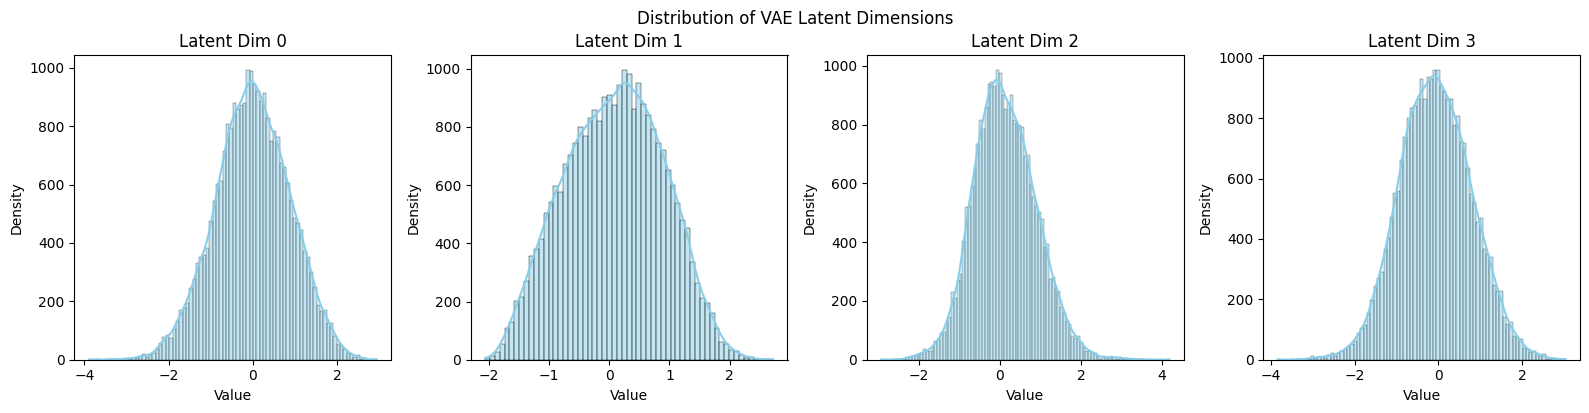

In [49]:
import seaborn as sns
import matplotlib.pyplot as plt

latent_dim = means.shape[1]
fig, axs = plt.subplots(nrows=1, ncols=4, figsize=(16, 4))  

for i in range(latent_dim):
    sns.histplot(means[:, i], kde=True, ax=axs[i], color="skyblue")
    axs[i].set_title(f"Latent Dim {i}")
    axs[i].set_xlabel("Value")
    axs[i].set_ylabel("Density")

plt.tight_layout()
plt.suptitle("Distribution of VAE Latent Dimensions", fontsize=12, y=1.02)
plt.show()

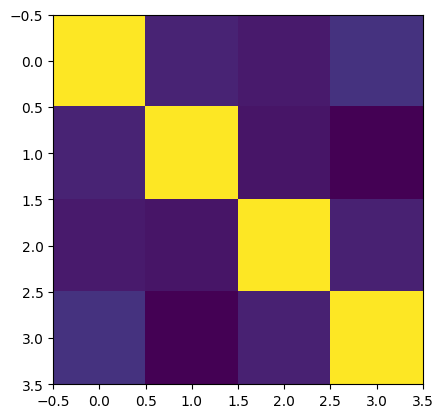

In [50]:
plt.imshow(np.corrcoef(means.T))

In [51]:
import matplotlib.pyplot as plt

def plot_single_reconstruction(vae, data_tensor, index=2):
    vae.eval()
    with torch.no_grad():
        x = data_tensor[index].unsqueeze(0)  # batch dim
        x_hat, mu, logvar = vae(x)
        # print(mu,logvar,x_hat)
    original = x.squeeze().cpu().numpy()
    reconstructed = x_hat.squeeze().cpu().numpy()

    plt.figure(figsize=(8, 6))
    plt.plot(original, label="Original", color="blue")
    plt.plot(reconstructed, label="Reconstructed", color="orange", linestyle='--')
    plt.title(f"Original vs Reconstructed - Jump Index: {index}")
    plt.xlabel("Step")
    plt.ylabel("Force")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

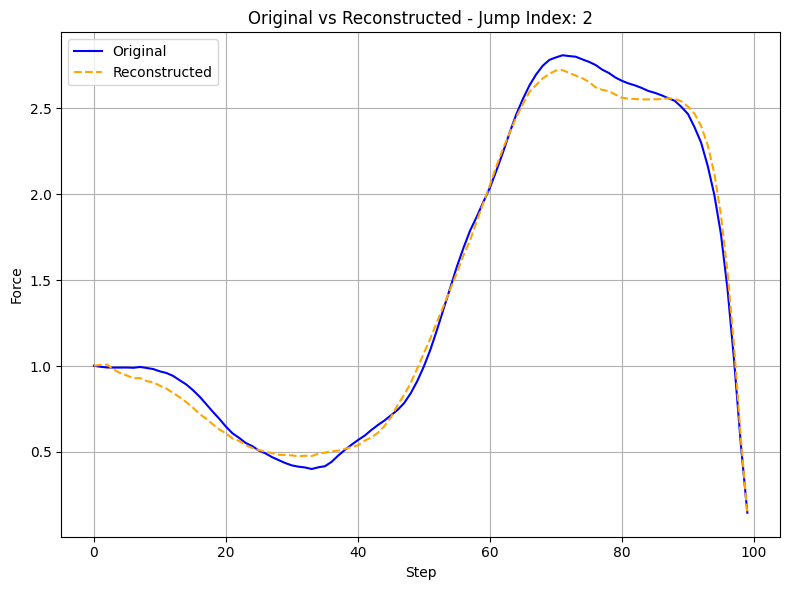

In [52]:
for i in range(2,3):
    plot_single_reconstruction(vae, downsampled_tensor, index=i)

In [53]:
import statsmodels.api as sm
import pandas as pd
import numpy as np

X_latent_4d = np.stack(data["vae_latent_space_4d"].values)
X_df = pd.DataFrame(X_latent_4d, columns=["Latent1", "Latent2", "Latent3", "Latent4"]).reset_index(drop=True)

y = data["JUMP_HEIGHT_INCHES"].reset_index(drop=True)

X_with_const = sm.add_constant(X_df)

model = sm.OLS(y, X_with_const).fit()

print(model.summary())


                            OLS Regression Results                            
Dep. Variable:     JUMP_HEIGHT_INCHES   R-squared:                       0.602
Model:                            OLS   Adj. R-squared:                  0.602
Method:                 Least Squares   F-statistic:                     9923.
Date:                Wed, 23 Apr 2025   Prob (F-statistic):               0.00
Time:                        21:48:38   Log-Likelihood:                -60317.
No. Observations:               26217   AIC:                         1.206e+05
Df Residuals:                   26212   BIC:                         1.207e+05
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         16.4294      0.015   1076.086      0.0

In [54]:
coefficients = model.params

tensor([-1.0054,  0.0871,  0.1341, -0.0645])
tensor([-0.5054,  0.0871,  0.1341, -0.0645])
tensor([ 0.4946,  0.0871,  0.1341, -0.0645])
tensor([ 0.9946,  0.0871,  0.1341, -0.0645])


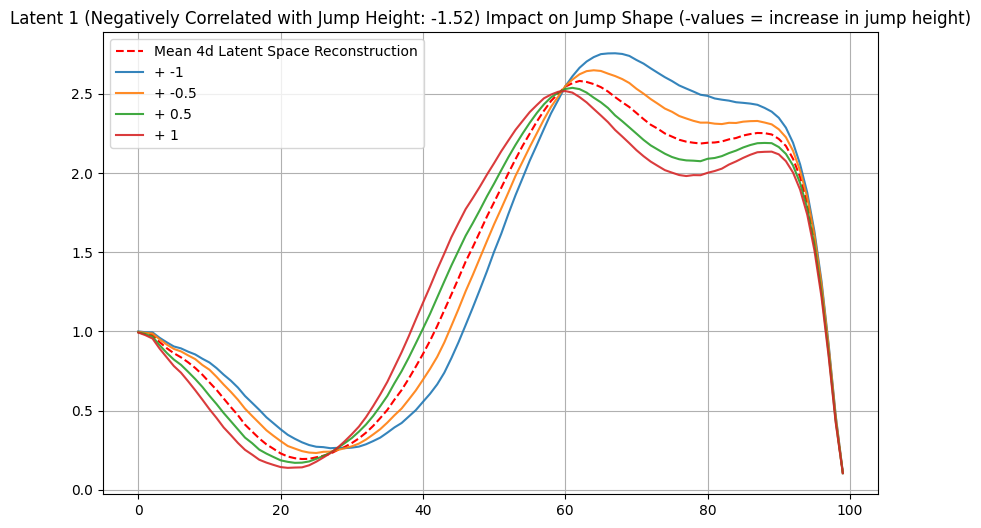

tensor([-0.0054,  0.0871,  0.1341, -0.0645])


In [55]:
mean_tensor = torch.tensor(np.mean(data["vae_latent_space_4d"])).float()

scaling_factors = [-1, -0.5, 0.5, 1] 
scaled_latent_1 = {}

count = 0

for i in scaling_factors:
    latent_1_modification = mean_tensor.clone()
    new_latent_1_val = latent_1_modification[0] + i
    latent_1_modification[0] = new_latent_1_val
    scaled_latent_1[str(i)] = latent_1_modification
    count += 1

mean_reconstruction = vae.decode(mean_tensor.unsqueeze(0)).detach().cpu().numpy()[0]
scaled_latent_1_reconstructions = {}

scaled_latent_1
for key, latent_vector in scaled_latent_1.items():
    print(latent_vector)
    scaled_latent_1_reconstructions[str(key)] = vae.decode(latent_vector.unsqueeze(0)).detach().cpu().numpy()[0]

    
plt.figure(figsize=(10, 6))
plt.plot(mean_reconstruction, label="Mean 4d Latent Space Reconstruction", linestyle='--', color='red')

for key, reconstruction in scaled_latent_1_reconstructions.items():
    plt.plot(reconstruction, label=f"+ {key}", alpha=0.9)

latent1_coef = round(coefficients["Latent1"], 3)
    
if latent1_coef > 0:
    plt.title(f"Latent 1 (Positively Correlated with Jump Height: {latent1_coef}) Impact on Jump Shape (+values = increase in jump height)")
else:
    plt.title(f"Latent 1 (Negatively Correlated with Jump Height: {latent1_coef}) Impact on Jump Shape (-values = increase in jump height)")
    
plt.legend()
plt.grid(True)
plt.savefig("latent1_effect_on_jump.png", dpi=300)

plt.show()
print(mean_tensor)

tensor([-0.0054, -0.9129,  0.1341, -0.0645])
tensor([-0.0054, -0.4129,  0.1341, -0.0645])
tensor([-0.0054,  0.5871,  0.1341, -0.0645])
tensor([-0.0054,  1.0871,  0.1341, -0.0645])


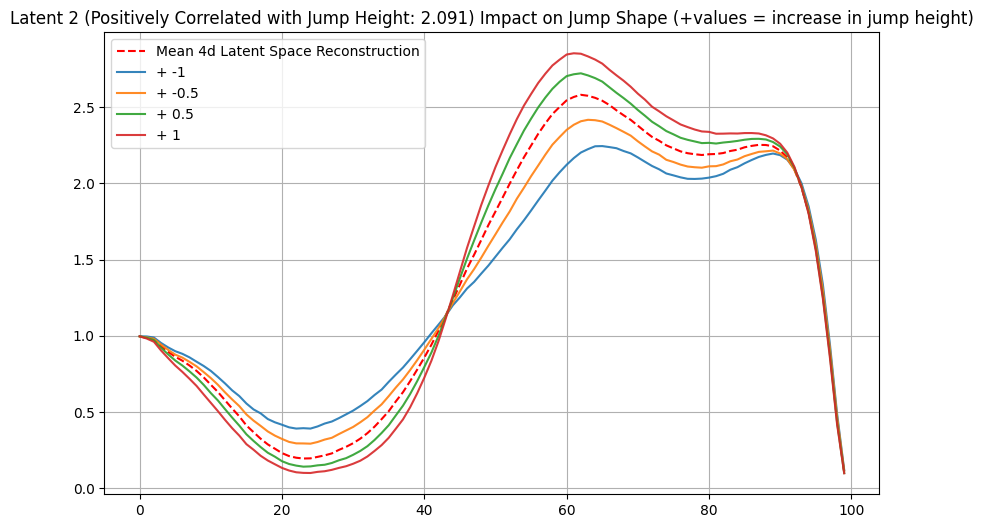

In [56]:
mean_tensor = torch.tensor(np.mean(data["vae_latent_space_4d"])).float()

# scaling_factors = [1, -1] 
scaled_latent_2 = {}

count = 0

for i in scaling_factors:
    latent_2_modification = mean_tensor.clone()
    new_latent_2_val = latent_2_modification[1] + i
    latent_2_modification[1] = new_latent_2_val
    scaled_latent_2[str(i)] = latent_2_modification
    count += 1

mean_reconstruction = vae.decode(mean_tensor.unsqueeze(0)).detach().cpu().numpy()[0]
scaled_latent_2_reconstructions = {}


for key, latent_vector in scaled_latent_2.items():
    print(latent_vector)
    scaled_latent_2_reconstructions[str(key)] = vae.decode(latent_vector.unsqueeze(0)).detach().cpu().numpy()[0]

    
plt.figure(figsize=(10, 6))
plt.plot(mean_reconstruction, label="Mean 4d Latent Space Reconstruction", linestyle='--', color='red')

for key, reconstruction in scaled_latent_2_reconstructions.items():
    plt.plot(reconstruction, label=f"+ {key}", alpha=0.9)
    
latent2_coef = round(coefficients["Latent2"], 3)

    
if latent2_coef > 0:
    plt.title(f"Latent 2 (Positively Correlated with Jump Height: {latent2_coef}) Impact on Jump Shape (+values = increase in jump height)")
else:
    plt.title(f"Latent 2 (Negatively Correlated with Jump Height: {latent2_coef}) Impact on Jump Shape (-values = increase in jump height)")

plt.legend()
plt.grid(True)
plt.savefig("latent2_effect_on_jump.png", dpi=300)

plt.show()

tensor([-0.0054,  0.0871, -0.8659, -0.0645])
tensor([-0.0054,  0.0871, -0.3659, -0.0645])
tensor([-0.0054,  0.0871,  0.6341, -0.0645])
tensor([-0.0054,  0.0871,  1.1341, -0.0645])


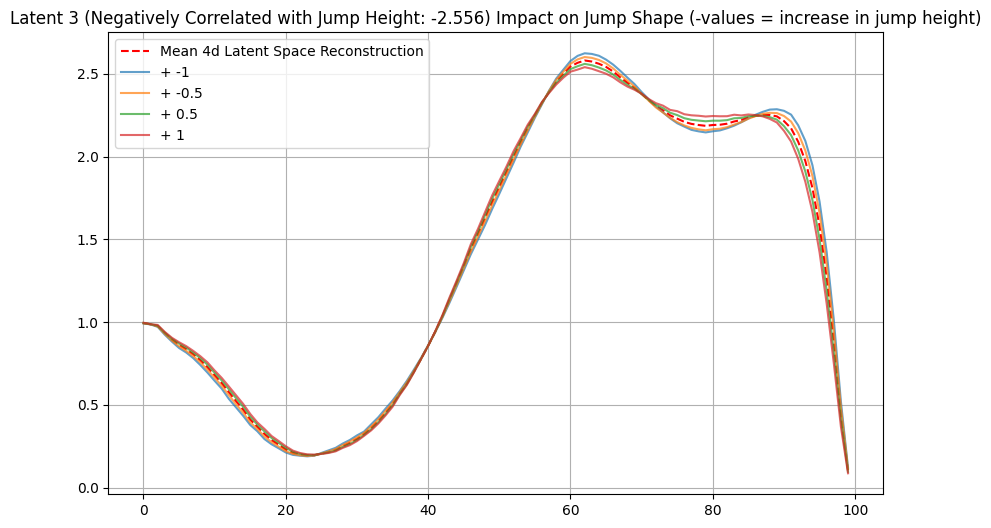

In [57]:
mean_tensor = torch.tensor(np.mean(data["vae_latent_space_4d"])).float()

# scaling_factors = [2, -2] 
scaled_latent_3 = {}

count = 0

for i in scaling_factors:
    latent_3_modification = mean_tensor.clone()
    new_latent_3_val = latent_3_modification[2] + i
    latent_3_modification[2] = new_latent_3_val
    scaled_latent_3[str(i)] = latent_3_modification
    count += 1

mean_reconstruction = vae.decode(mean_tensor.unsqueeze(0)).detach().cpu().numpy()[0]
scaled_latent_3_reconstructions = {}

scaled_latent_3
for key, latent_vector in scaled_latent_3.items():
    print(latent_vector)
    scaled_latent_3_reconstructions[str(key)] = vae.decode(latent_vector.unsqueeze(0)).detach().cpu().numpy()[0]

    
plt.figure(figsize=(10, 6))
plt.plot(mean_reconstruction, label="Mean 4d Latent Space Reconstruction", linestyle='--', color='red')

for key, reconstruction in scaled_latent_3_reconstructions.items():
    plt.plot(reconstruction, label=f"+ {key}", alpha=0.7)
    
latent3_coef = round(coefficients["Latent3"], 3)
    
if latent3_coef > 0:
    plt.title(f"Latent 3 (Positively Correlated with Jump Height: {latent3_coef}) Impact on Jump Shape (+values = increase in jump height)")
else:
    plt.title(f"Latent 3 (Negatively Correlated with Jump Height: {latent3_coef}) Impact on Jump Shape (-values = increase in jump height)")
    
plt.legend()
plt.grid(True)
plt.savefig("latent3_effect_on_jump.png", dpi=300)

plt.show()

tensor([-0.0054,  0.0871,  0.1341, -1.0645])
tensor([-0.0054,  0.0871,  0.1341, -0.5645])
tensor([-0.0054,  0.0871,  0.1341,  0.4355])
tensor([-0.0054,  0.0871,  0.1341,  0.9355])


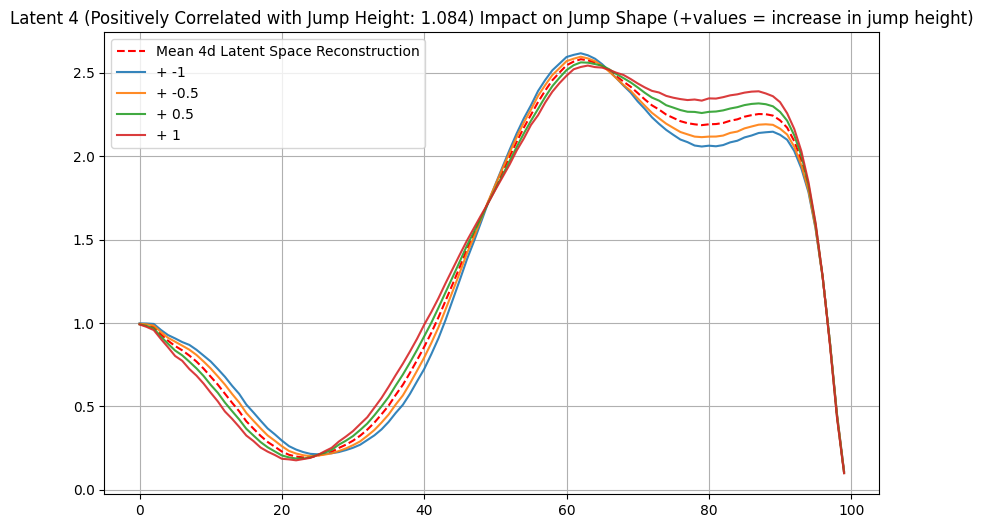

tensor([-0.0054,  0.0871,  0.1341, -0.0645])


In [58]:
mean_tensor = torch.tensor(np.mean(data["vae_latent_space_4d"])).float()

# scaling_factors = [1, -1] 
scaled_latent_4 = {}

count = 0

for i in scaling_factors:
    latent_4_modification = mean_tensor.clone()
    new_latent_4_val = latent_4_modification[3] + i
    latent_4_modification[3] = new_latent_4_val
    scaled_latent_4[str(i)] = latent_4_modification
    count += 1

mean_reconstruction = vae.decode(mean_tensor.unsqueeze(0)).detach().cpu().numpy()[0]
scaled_latent_4_reconstructions = {}

scaled_latent_1
for key, latent_vector in scaled_latent_4.items():
    print(latent_vector)
    scaled_latent_4_reconstructions[str(key)] = vae.decode(latent_vector.unsqueeze(0)).detach().cpu().numpy()[0]

    
plt.figure(figsize=(10, 6))
plt.plot(mean_reconstruction, label="Mean 4d Latent Space Reconstruction", linestyle='--', color='red')

for key, reconstruction in scaled_latent_4_reconstructions.items():
    plt.plot(reconstruction, label=f"+ {key}", alpha=0.9)
    
latent4_coef = round(coefficients["Latent4"], 3)
if latent4_coef > 0:
    plt.title(f"Latent 4 (Positively Correlated with Jump Height: {latent4_coef}) Impact on Jump Shape (+values = increase in jump height)")
else:
    plt.title(f"Latent 4 (Negatively Correlated with Jump Height: {latent4_coef}) Impact on Jump Shape (-values = increase in jump height)")

plt.legend()
plt.grid(True)
plt.savefig("latent4_effect_on_jump.png", dpi=300)

plt.show()

print(mean_tensor)

### Consistency Analysis

In [59]:
# latent_4d = np.stack(data["vae_latent_space_4d"].values)


In [60]:
# from sklearn.manifold import TSNE
# from sklearn.cluster import KMeans

# kmeans = KMeans(n_clusters=4, random_state=42)

# sample_size = int(len(latent_4d) * 0.1)  
# latent_4d_sample = latent_4d[np.random.choice(latent_4d.shape[0], sample_size, replace=False)]

# tsne = TSNE(n_components=2, perplexity=30, random_state=42)
# latent_2d_sample = tsne.fit_transform(latent_4d_sample)

# cluster_labels_sample = kmeans.fit_predict(latent_4d_sample)

In [61]:
# data["downsampled_time_series"]

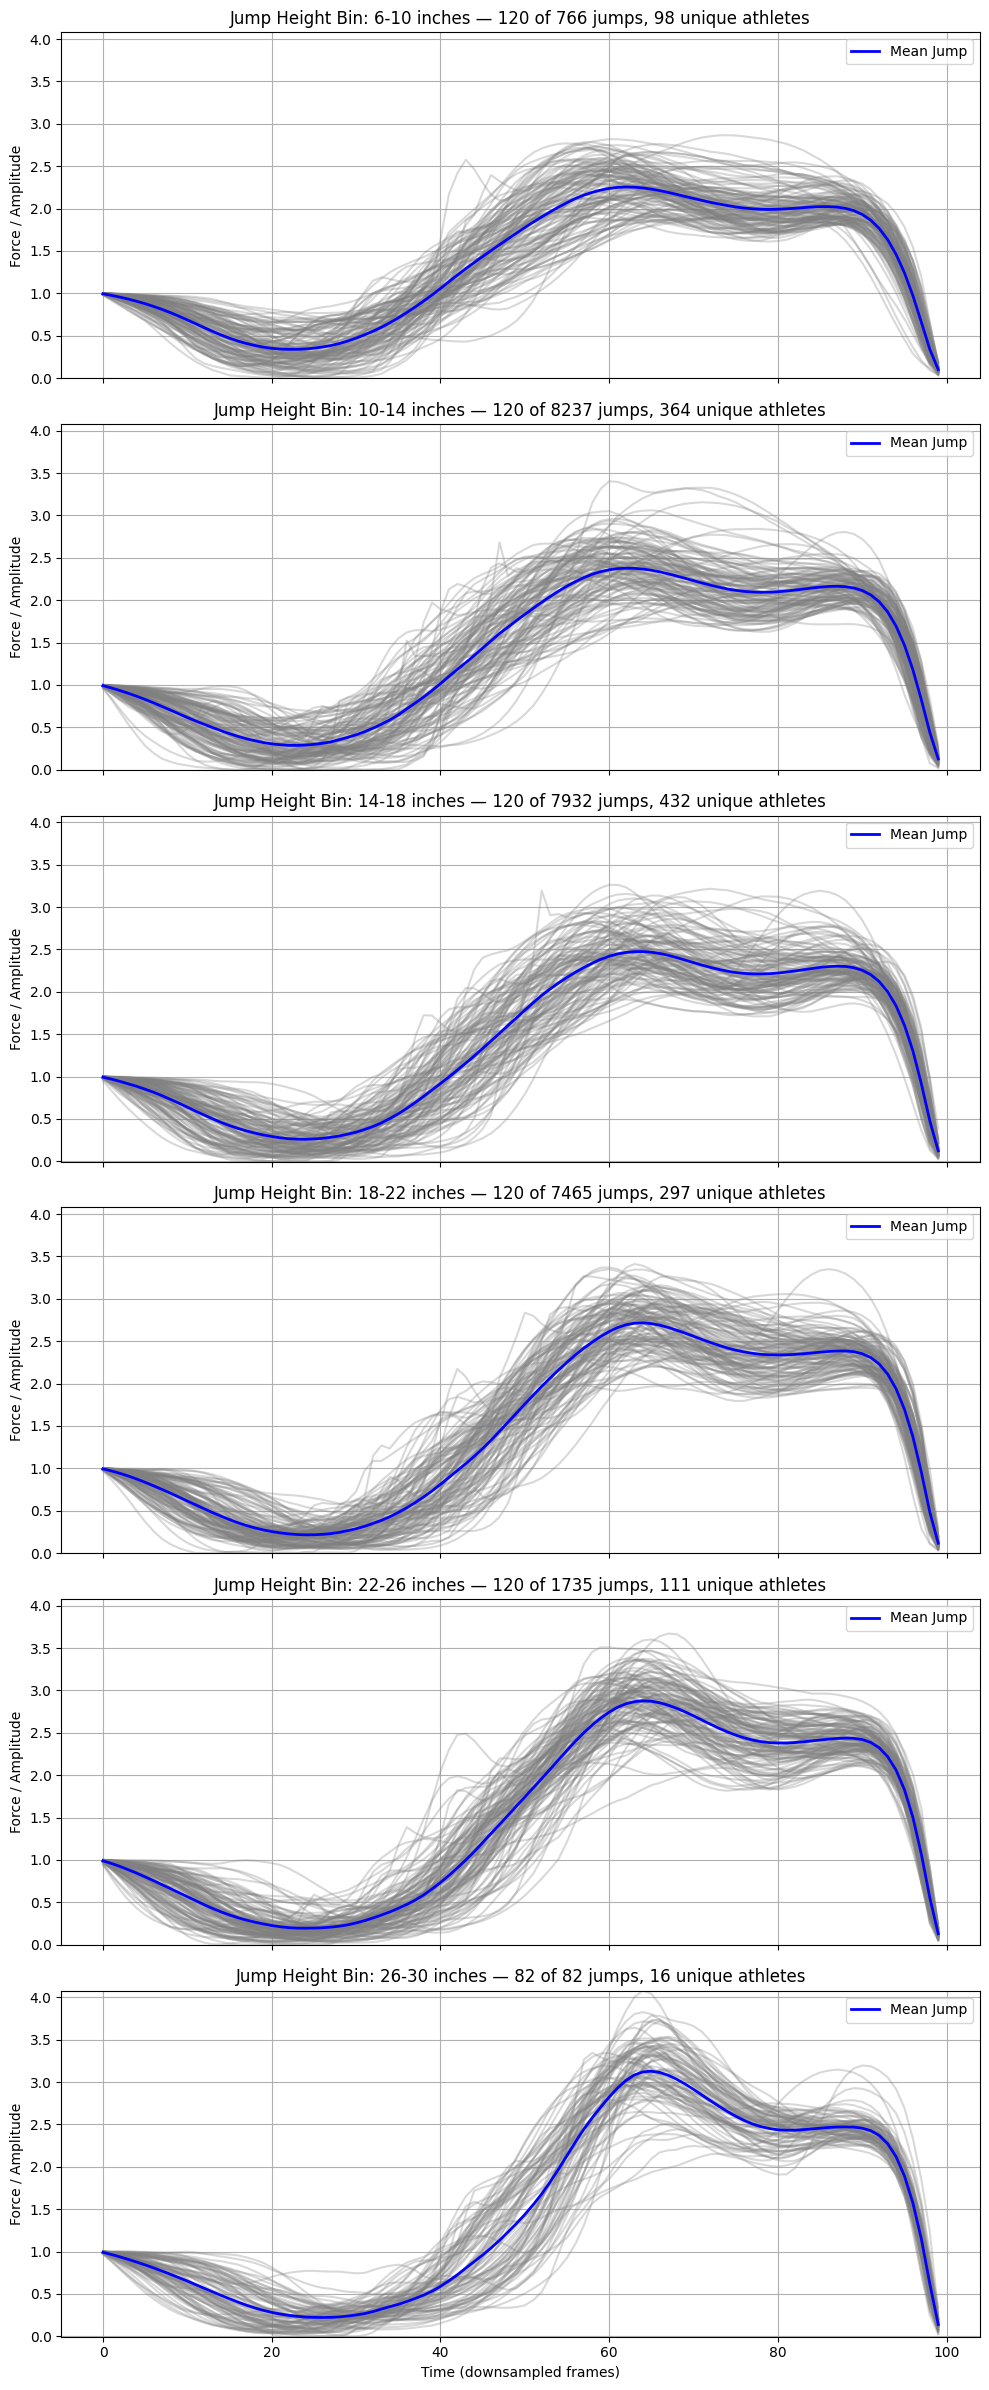

In [75]:
import math
from pandas.api.types import CategoricalDtype

BIN_SIZE = 4  # inches per bin
MAX_JUMPS_PER_BIN = 120  # max jumps to sample per bin

# Filter and bin
binned_data = data.dropna(subset=["JUMP_HEIGHT_INCHES", "downsampled_time_series"])
binned_data = binned_data[binned_data["JUMP_HEIGHT_INCHES"] > 6]

min_height = math.floor(binned_data["JUMP_HEIGHT_INCHES"].min())
max_height = math.ceil(binned_data["JUMP_HEIGHT_INCHES"].max())
bins = np.arange(min_height, max_height + BIN_SIZE, BIN_SIZE)
bin_labels = [f"{int(b)}-{int(b + BIN_SIZE)}" for b in bins[:-1]]

binned_data["jump_bin"] = pd.cut(
    binned_data["JUMP_HEIGHT_INCHES"],
    bins=bins,
    labels=bin_labels,
    include_lowest=True
)
cat_type = CategoricalDtype(categories=bin_labels, ordered=True)
binned_data["jump_bin"] = binned_data["jump_bin"].astype(cat_type)

unique_bins = sorted(binned_data["jump_bin"].dropna().unique(), key=lambda x: bin_labels.index(str(x)))
n_bins = len(unique_bins)

# Step 1: Determine global y-limits
y_min, y_max = np.inf, -np.inf
for bin_label in unique_bins:
    group = binned_data[binned_data["jump_bin"] == bin_label]
    group_sample = group.sample(n=min(MAX_JUMPS_PER_BIN, len(group)))
    try:
        jump_matrix = np.stack(group_sample["downsampled_time_series"].values)
        y_min = min(y_min, jump_matrix.min())
        y_max = max(y_max, jump_matrix.max())
    except Exception as e:
        print(f"Error computing global y-limits for bin {bin_label}: {e}")

# Step 2: Plot with consistent y-axis
fig, axes = plt.subplots(n_bins, 1, figsize=(10, 4 * n_bins), sharex=True)
if n_bins == 1:
    axes = [axes]  

for ax, bin_label in zip(axes, unique_bins):
    group = binned_data[binned_data["jump_bin"] == bin_label]
    group_sample = group.sample(n=min(MAX_JUMPS_PER_BIN, len(group)))  

    for _, row in group_sample.iterrows():
        ax.plot(row["downsampled_time_series"], color='gray', alpha=0.3)

    try:
        jump_matrix = np.stack(group_sample["downsampled_time_series"].values)
        mean_jump = jump_matrix.mean(axis=0)
        ax.plot(mean_jump, color='blue', linewidth=2, label='Mean Jump')
    except Exception as e:
        print(f"Skipping mean plot for bin {bin_label}: {e}")

    unique_athletes = group["profileID"].nunique()
    ax.set_title(
        f"Jump Height Bin: {bin_label} inches — "
        f"{len(group_sample)} of {len(group)} jumps, "
        f"{unique_athletes} unique athletes"
    )
    ax.set_ylabel("Force / Amplitude")
    ax.set_ylim(y_min, y_max)
    ax.grid(True)
    ax.legend()

axes[-1].set_xlabel("Time (downsampled frames)")
plt.tight_layout()
plt.show()


In [76]:
data.head(1)

,Unnamed: 0.1,Unnamed: 0,testID,rep,profileID,recordedUTC,Team,Category,BODY_WEIGHT_N,BODY_WEIGHT,BODY_WEIGHT_LBS,START_OF_MOVEMENT,BEGIN_CONCENTRIC_PHASE,BEGIN_BRAKING_PHASE,BEGIN_ECC_DECEL_PHASE,START_OF_MOVEMENT_THRESHOLD,START_OF_INTEGRATION,JUMP_HEIGHT_INCHES,JUMP_HEIGHT_INCHES_IMP_MOM,FLIGHT_TIME,JUMP_HEIGHT,IMPULSE_JUMP_HEIGHT,JUMP_HEIGHT_IMP_MOM,WEIGHT_RELATIVE_PEAK_LANDING_FORCE,POSITIVE_IMPULSE,JUMP_HEIGHT_RELATIVE_LANDING_RFD,JUMP_HEIGHT_RELATIVE_PEAK_LANDING_FORCE,LANDING_RFD,MEAN_LANDING_ACCELERATION,MEAN_LANDING_POWER,MEAN_LANDING_VELOCITY,PEAK_LANDING_ACCELERATION,PEAK_LANDING_FORCE,PEAK_LANDING_POWER,PEAK_LANDING_VELOCITY,RELATIVE_PEAK_LANDING_FORCE,LANDING_IMPULSE,LANDING_RFD_50,MEAN_ECCENTRIC_FORCE,MEAN_ECCENTRIC_POWER,BODYMASS_RELATIVE_MEAN_ECCENTRIC_POWER,RELATIVE_ECCENTRIC_BRAKING_RFD,ECCENTRIC_BRAKING_IMPULSE,MEAN_ECCENTRIC_BRAKING_FORCE,MEAN_ECCENTRIC_DECELERATION_FORCE,ECCENTRIC_BRAKING_RFD,ECCENTRIC_DECEL_RFD,RELATIVE_ECCENTRIC_DECEL_RFD,PEAK_ECCENTRIC_FORCE,RELATIVE_PEAK_ECCENTRIC_FORCE,LOWER_LIMB_STIFFNESS,ECCENTRIC_DECEL_IMPULSE,BODYMASS_RELATIVE_ECCENTRIC_PEAK_POWER,MIN_ECCENTRIC_FORCE,ECCENTRIC_BRAKING_RFD_100MS,RELATIVE_ECCENTRIC_BRAKING_RFD_100MS,ECCENTRIC_PEAK_VELOCITY,ECCENTRIC_PEAK_POWER,BODYMASS_RELATIVE_ECC_DECEL_IMPULSE,RSI_MODIFIED,RSI_MODIFIED_IMP_MOM,MEAN_ECC_CON_RATIO,FORCE_AT_PEAK_POWER,CONTRACTION_TIME,ECCENTRIC_TIME,TIME_TO_PEAK_FORCE,START_TO_PEAK_FORCE_TIME,START_TO_PEAK_POWER_TIME,CONCENTRIC_DURATION,CONCENTRIC_ECCENTRIC_DURATION_RATIO,ECCENTRIC_CONCENTRIC_DURATION_RATIO,FLIGHT_CONTRACTION_TIME_RATIO,FLIGHT_ECCENTRIC_TIME_RATIO,BRAKING_PHASE_DURATION,TIME_TO_BRAKING_PHASE,ECCENTRIC_ACCEL_PHASE_DURATION,ECCENTRIC_DECEL_PHASE_DURATION,BEAKING_CONTRACTION_DURATION_RATIO,BEAKING_CONCENTRIC_DURATION_RATIO,MEAN_ECC_CON_POWER_TIME,FORCE_AT_ZERO_VELOCITY,ECC_CON_PEAK_POWER_RATIO,CON_P2_CON_P1_IMPULSE_RATIO,CON_100MS_CON_IMPULSE_RATIO,BM_REL_FORCE_AT_ZERO_VELOCITY,COUNTERMOVEMENT_DEPTH,DISPLACEMENT_AT_TAKEOFF,BODYMASS_RELATIVE_TAKEOFF_POWER,MEAN_TAKEOFF_FORCE,MEAN_CONCENTRIC_POWER,BODYMASS_RELATIVE_MEAN_CONCENTRIC_POWER,MEAN_TAKEOFF_VELOCITY,PEAK_TAKEOFF_FORCE,PEAK_TAKEOFF_POWER,PEAK_TAKEOFF_VELOCITY,TAKEOFF_VELOCITY,RELATIVE_PEAK_TAKEOFF_FORCE,PEAK_CONCENTRIC_FORCE,RELATIVE_PEAK_CONCENTRIC_FORCE,CONCENTRIC_IMPULSE,POSITIVE_TAKEOFF_IMPULSE,BODYMASS_RELATIVE_MEAN_TAKEOFF_FORCE,BM_REL_ABS_CON_IMPULSE,MEAN_TAKEOFF_ACCELERATION,CONCENTRIC_RFD,CONCENTRIC_RFD_MAX,RELATIVE_CONCENTRIC_RFD,CONCENTRIC_RPD,RELATIVE_CONCENTRIC_RPD,PEAK_TAKEOFF_ACCELERATION,CONCENTRIC_RFD_100,CONCENTRIC_RFD_200,CONCENTRIC_RFD_50,WEIGHT_RELATIVE_PEAK_TAKEOFF_FORCE,CONCENTRIC_IMPULSE_50MS,CONCENTRIC_IMPULSE_100MS,CONCENTRIC_IMPULSE_P1,CONCENTRIC_IMPULSE_P2,CONCENTRIC_RPD_50MS,RELATIVE_CONCENTRIC_RPD_50MS,CONCENTRIC_RPD_100MS,RELATIVE_CONCENTRIC_RPD_100MS,TOTAL_WORK,VELOCITY_AT_PEAK_POWER,CMJ_STIFFNESS,ECCENTRIC_UNLOADING_IMPULSE,id_rep,time_series,total_force,initial_value,normalized_time_series,downsampled_time_series,latent_space_consistency,reconstruction_loss,reconstruction,outlier,total_sessions,start_year,years_training,first_session_date,relative_session,latent_0,latent_1,latent_2,latent_3,latent_4,latent_5,latent_6,latent_7,latent_8,latent_9,latent_10,latent_11,latent_12,latent_13,latent_14,latent_15,initial_weight,jump_end_time,vae_latent_space_4d
0,0,0,f6b0b4f3-ccaa-488c-b71b-2a9d6fd8c359,1,eb037fd9-1b41-4bee-ade5-079f3d3012f8,2023-01-06 23:31:43.937000+00:00,Acro and Tumbling,Sport,NaN,NaN,NaN,10.206,10.628,10.37,10.46,18.494496,10.206,8.676187,8.861041,0.424,22.037504,22.51405,22.507032,40.056,result\nPOSITIVE_IMPULSE 305.515939\nPOSITI...,2013.020207,124.807,result\nLANDING_RFD 44361.941\nLANDING_RFD ...,1.851,242.302,-0.095,40.056,result\nPEAK_LANDING_FORCE 2750.440318\nPEA...,3826.224,0.389,49.86295,result\nLANDING_IMPULSE 74.115300\nLANDING_...,35920.0,result\nMEAN_ECCENTRIC_FORCE 541.478054\nME...,216.720458,3.928942,57.900625,result\nECCENTRIC_BRAKING_IMPULSE 24.932420...,637.786472,794.063848,result\n

### Do Athletes Approach a Tighter Jump Shape as Jump Height Increases?
- For each jump in a bin (every 5 inches), calculate both the mean jump for that bin, then calculate the Euclidean distance between their 4D latent space and the mean jump
- For higher jumps, if the differences are lower, that means the shapes are closer togther as there is less variation between all jumps and the mean jump for that bin. 

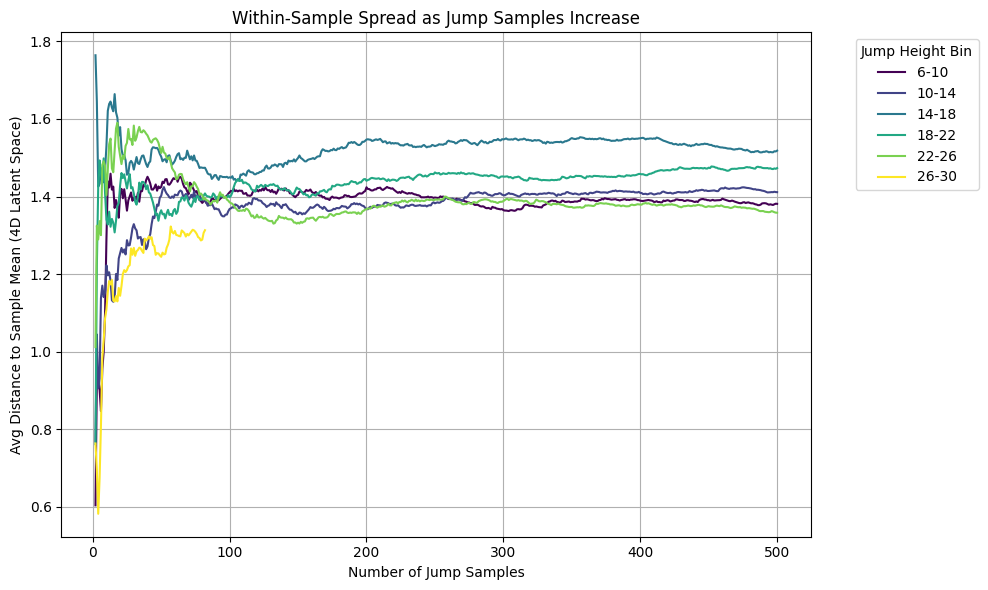

In [77]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.spatial.distance import euclidean

plt.figure(figsize=(10, 6))

max_sample_limit = 500
colors = plt.cm.viridis(np.linspace(0, 1, len(bin_labels)))

for idx, bin_label in enumerate(bin_labels):
    group = binned_data[binned_data["jump_bin"] == bin_label]

    latent_matrix = np.stack(group["vae_latent_space_4d"].values)
    n_samples = latent_matrix.shape[0]

    np.random.seed(42)
    shuffled = latent_matrix[np.random.permutation(n_samples)]

    within_sample_spread = []
    sample_sizes = range(2, min(max_sample_limit, n_samples) + 1)

    for i in sample_sizes:
        subset = shuffled[:i]
        current_mean = subset.mean(axis=0)
        distances = [euclidean(vec, current_mean) for vec in subset]
        avg_distance = np.mean(distances)
        within_sample_spread.append(avg_distance)

    plt.plot(sample_sizes, within_sample_spread, label=str(bin_label), color=colors[idx])

plt.xlabel("Number of Jump Samples")
plt.ylabel("Avg Distance to Sample Mean (4D Latent Space)")
plt.title("Within-Sample Spread as Jump Samples Increase")
plt.legend(title="Jump Height Bin", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.grid(True)
plt.tight_layout()
plt.show()


In [78]:
# randomly resample with replacement, recalcuqate mean and average deviation to get confidnece interval
# resample to get error bars, distribution of avg distance to bin mean, is it statistically significant, do the next values fall out of 95% range
# bootstrap 1000 samples 


# resample latent space in bins 
# plot average distance to sample mean

In [79]:
binned_data.head(1)

,Unnamed: 0.1,Unnamed: 0,testID,rep,profileID,recordedUTC,Team,Category,BODY_WEIGHT_N,BODY_WEIGHT,BODY_WEIGHT_LBS,START_OF_MOVEMENT,BEGIN_CONCENTRIC_PHASE,BEGIN_BRAKING_PHASE,BEGIN_ECC_DECEL_PHASE,START_OF_MOVEMENT_THRESHOLD,START_OF_INTEGRATION,JUMP_HEIGHT_INCHES,JUMP_HEIGHT_INCHES_IMP_MOM,FLIGHT_TIME,JUMP_HEIGHT,IMPULSE_JUMP_HEIGHT,JUMP_HEIGHT_IMP_MOM,WEIGHT_RELATIVE_PEAK_LANDING_FORCE,POSITIVE_IMPULSE,JUMP_HEIGHT_RELATIVE_LANDING_RFD,JUMP_HEIGHT_RELATIVE_PEAK_LANDING_FORCE,LANDING_RFD,MEAN_LANDING_ACCELERATION,MEAN_LANDING_POWER,MEAN_LANDING_VELOCITY,PEAK_LANDING_ACCELERATION,PEAK_LANDING_FORCE,PEAK_LANDING_POWER,PEAK_LANDING_VELOCITY,RELATIVE_PEAK_LANDING_FORCE,LANDING_IMPULSE,LANDING_RFD_50,MEAN_ECCENTRIC_FORCE,MEAN_ECCENTRIC_POWER,BODYMASS_RELATIVE_MEAN_ECCENTRIC_POWER,RELATIVE_ECCENTRIC_BRAKING_RFD,ECCENTRIC_BRAKING_IMPULSE,MEAN_ECCENTRIC_BRAKING_FORCE,MEAN_ECCENTRIC_DECELERATION_FORCE,ECCENTRIC_BRAKING_RFD,ECCENTRIC_DECEL_RFD,RELATIVE_ECCENTRIC_DECEL_RFD,PEAK_ECCENTRIC_FORCE,RELATIVE_PEAK_ECCENTRIC_FORCE,LOWER_LIMB_STIFFNESS,ECCENTRIC_DECEL_IMPULSE,BODYMASS_RELATIVE_ECCENTRIC_PEAK_POWER,MIN_ECCENTRIC_FORCE,ECCENTRIC_BRAKING_RFD_100MS,RELATIVE_ECCENTRIC_BRAKING_RFD_100MS,ECCENTRIC_PEAK_VELOCITY,ECCENTRIC_PEAK_POWER,BODYMASS_RELATIVE_ECC_DECEL_IMPULSE,RSI_MODIFIED,RSI_MODIFIED_IMP_MOM,MEAN_ECC_CON_RATIO,FORCE_AT_PEAK_POWER,CONTRACTION_TIME,ECCENTRIC_TIME,TIME_TO_PEAK_FORCE,START_TO_PEAK_FORCE_TIME,START_TO_PEAK_POWER_TIME,CONCENTRIC_DURATION,CONCENTRIC_ECCENTRIC_DURATION_RATIO,ECCENTRIC_CONCENTRIC_DURATION_RATIO,FLIGHT_CONTRACTION_TIME_RATIO,FLIGHT_ECCENTRIC_TIME_RATIO,BRAKING_PHASE_DURATION,TIME_TO_BRAKING_PHASE,ECCENTRIC_ACCEL_PHASE_DURATION,ECCENTRIC_DECEL_PHASE_DURATION,BEAKING_CONTRACTION_DURATION_RATIO,BEAKING_CONCENTRIC_DURATION_RATIO,MEAN_ECC_CON_POWER_TIME,FORCE_AT_ZERO_VELOCITY,ECC_CON_PEAK_POWER_RATIO,CON_P2_CON_P1_IMPULSE_RATIO,CON_100MS_CON_IMPULSE_RATIO,BM_REL_FORCE_AT_ZERO_VELOCITY,COUNTERMOVEMENT_DEPTH,DISPLACEMENT_AT_TAKEOFF,BODYMASS_RELATIVE_TAKEOFF_POWER,MEAN_TAKEOFF_FORCE,MEAN_CONCENTRIC_POWER,BODYMASS_RELATIVE_MEAN_CONCENTRIC_POWER,MEAN_TAKEOFF_VELOCITY,PEAK_TAKEOFF_FORCE,PEAK_TAKEOFF_POWER,PEAK_TAKEOFF_VELOCITY,TAKEOFF_VELOCITY,RELATIVE_PEAK_TAKEOFF_FORCE,PEAK_CONCENTRIC_FORCE,RELATIVE_PEAK_CONCENTRIC_FORCE,CONCENTRIC_IMPULSE,POSITIVE_TAKEOFF_IMPULSE,BODYMASS_RELATIVE_MEAN_TAKEOFF_FORCE,BM_REL_ABS_CON_IMPULSE,MEAN_TAKEOFF_ACCELERATION,CONCENTRIC_RFD,CONCENTRIC_RFD_MAX,RELATIVE_CONCENTRIC_RFD,CONCENTRIC_RPD,RELATIVE_CONCENTRIC_RPD,PEAK_TAKEOFF_ACCELERATION,CONCENTRIC_RFD_100,CONCENTRIC_RFD_200,CONCENTRIC_RFD_50,WEIGHT_RELATIVE_PEAK_TAKEOFF_FORCE,CONCENTRIC_IMPULSE_50MS,CONCENTRIC_IMPULSE_100MS,CONCENTRIC_IMPULSE_P1,CONCENTRIC_IMPULSE_P2,CONCENTRIC_RPD_50MS,RELATIVE_CONCENTRIC_RPD_50MS,CONCENTRIC_RPD_100MS,RELATIVE_CONCENTRIC_RPD_100MS,TOTAL_WORK,VELOCITY_AT_PEAK_POWER,CMJ_STIFFNESS,ECCENTRIC_UNLOADING_IMPULSE,id_rep,time_series,total_force,initial_value,normalized_time_series,downsampled_time_series,latent_space_consistency,reconstruction_loss,reconstruction,outlier,total_sessions,start_year,years_training,first_session_date,relative_session,latent_0,latent_1,latent_2,latent_3,latent_4,latent_5,latent_6,latent_7,latent_8,latent_9,latent_10,latent_11,latent_12,latent_13,latent_14,latent_15,initial_weight,jump_end_time,vae_latent_space_4d,jump_bin
0,0,0,f6b0b4f3-ccaa-488c-b71b-2a9d6fd8c359,1,eb037fd9-1b41-4bee-ade5-079f3d3012f8,2023-01-06 23:31:43.937000+00:00,Acro and Tumbling,Sport,NaN,NaN,NaN,10.206,10.628,10.37,10.46,18.494496,10.206,8.676187,8.861041,0.424,22.037504,22.51405,22.507032,40.056,result\nPOSITIVE_IMPULSE 305.515939\nPOSITI...,2013.020207,124.807,result\nLANDING_RFD 44361.941\nLANDING_RFD ...,1.851,242.302,-0.095,40.056,result\nPEAK_LANDING_FORCE 2750.440318\nPEA...,3826.224,0.389,49.86295,result\nLANDING_IMPULSE 74.115300\nLANDING_...,35920.0,result\nMEAN_ECCENTRIC_FORCE 541.478054\nME...,216.720458,3.928942,57.900625,result\nECCENTRIC_BRAKING_IMPULSE 24.932420...,637.786472,794.063848

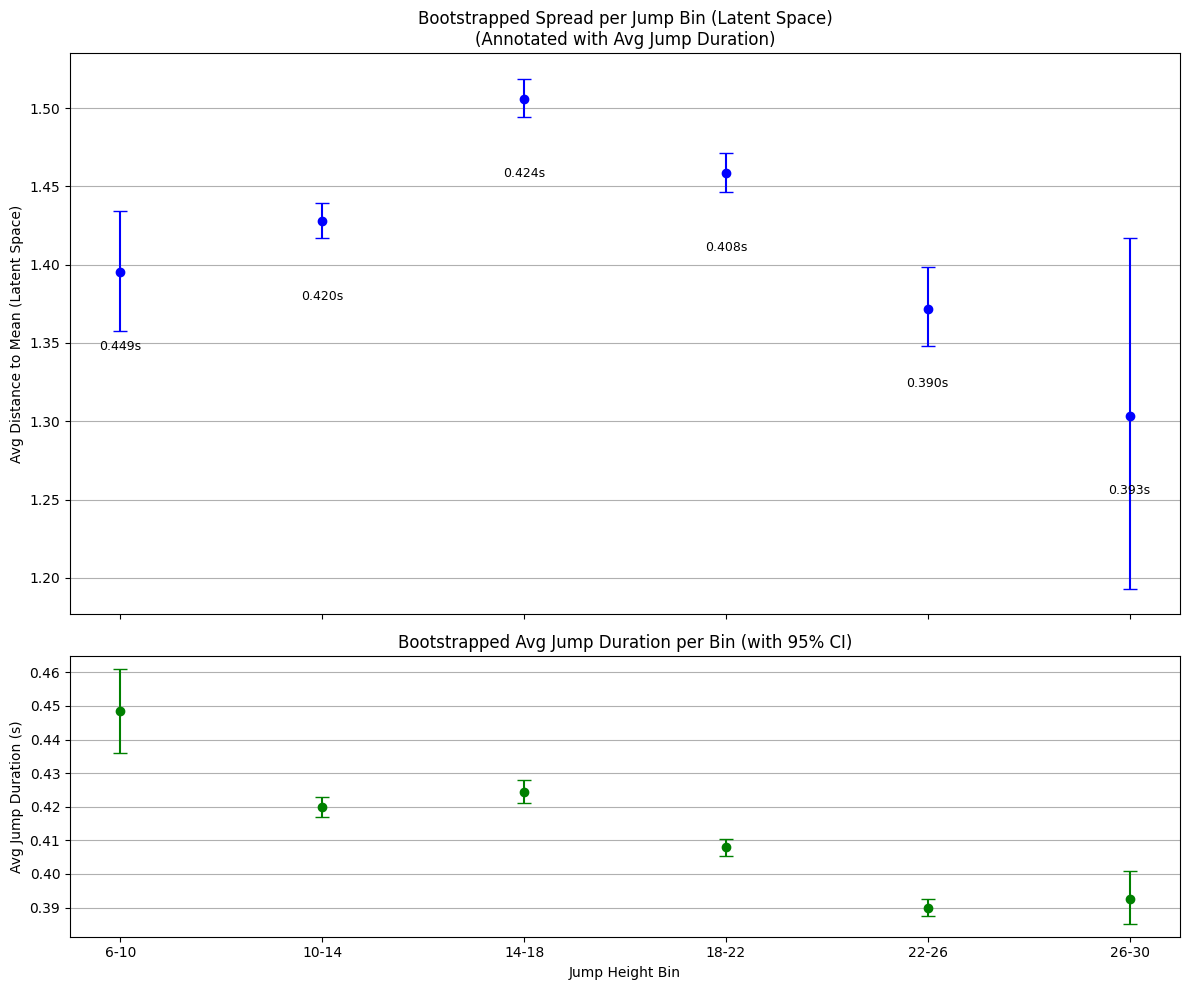

In [80]:
n_bootstrap = 1000
means = []
ci_lowers = []
ci_uppers = []
labels = []
sample_means = []

jump_end_means = []
jump_end_ci_lowers = []
jump_end_ci_uppers = []

for idx, bin_label in enumerate(bin_labels):
    group = binned_data[binned_data["jump_bin"] == bin_label]

    if group.empty:
        continue
    sample_means.append(group["vae_latent_space_4d"].mean())

    latent_matrix = np.stack(group["vae_latent_space_4d"].values)
    n_total = latent_matrix.shape[0]
    jump_end_array = group["jump_end_time"].values
    
    # sample_means.append(latent_matrix.mean())

    bootstrap_spreads = []
    for _ in range(n_bootstrap):
        sampled_indices = np.random.choice(n_total, size=n_total, replace=True)
        sample = latent_matrix[sampled_indices]
        sample_mean = sample.mean(axis=0)
        distances = np.linalg.norm(sample - sample_mean, axis=1)
        bootstrap_spreads.append(distances.mean())

    means.append(np.mean(bootstrap_spreads))
    ci_lowers.append(np.percentile(bootstrap_spreads, 2.5))
    ci_uppers.append(np.percentile(bootstrap_spreads, 97.5))
    labels.append(bin_label)

    jump_end_boots = []
    for _ in range(n_bootstrap):
        sampled = np.random.choice(jump_end_array, size=n_total, replace=True)
        jump_end_boots.append(sampled.mean())

    jump_end_means.append(np.mean(jump_end_boots))
    jump_end_ci_lowers.append(np.percentile(jump_end_boots, 2.5))
    jump_end_ci_uppers.append(np.percentile(jump_end_boots, 97.5))
    
    
# fig, ax1 = plt.subplots(figsize=(12, 6))

# ax1.errorbar(labels, means,
#              yerr=[np.array(means) - np.array(ci_lowers), np.array(ci_uppers) - np.array(means)],
#              fmt='o', capsize=5, linestyle='None', color='b')

# for i, avg_end in enumerate(jump_end_means):
#     ax1.text(i, means[i] - 0.05, f"{avg_end:.3f}s", ha='center', fontsize=9, color='black')

# ax1.set_ylabel("Avg Distance to Mean (Latent Space)")
# ax1.set_title("Bootstrapped Spread per Jump Bin (Latent Space)\n(Annotated with Avg Jump Duration)")
# ax1.grid(True, axis='y')

# plt.tight_layout()
# plt.savefig("bootstrapstuff.png", dpi=300)
# plt.show()


fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), sharex=True, gridspec_kw={'height_ratios': [2, 1]})

ax1.errorbar(labels, means,
             yerr=[np.array(means) - np.array(ci_lowers), np.array(ci_uppers) - np.array(means)],
             fmt='o', capsize=5, linestyle='None', color='b')

for i, avg_end in enumerate(jump_end_means):
    ax1.text(i, means[i] - 0.05, f"{avg_end:.3f}s", ha='center', fontsize=9, color='black')

ax1.set_ylabel("Avg Distance to Mean (Latent Space)")
ax1.set_title("Bootstrapped Spread per Jump Bin (Latent Space)\n(Annotated with Avg Jump Duration)")
ax1.grid(True, axis='y')

ax2.errorbar(labels, jump_end_means,
             yerr=[np.array(jump_end_means) - np.array(jump_end_ci_lowers),
                   np.array(jump_end_ci_uppers) - np.array(jump_end_means)],
             fmt='o', capsize=5, linestyle='None', color='green')

ax2.set_ylabel("Avg Jump Duration (s)")
ax2.set_xlabel("Jump Height Bin")
ax2.set_title("Bootstrapped Avg Jump Duration per Bin (with 95% CI)")
ax2.grid(True, axis='y')
plt.tight_layout()
plt.show()


In [81]:
# what is statistically 

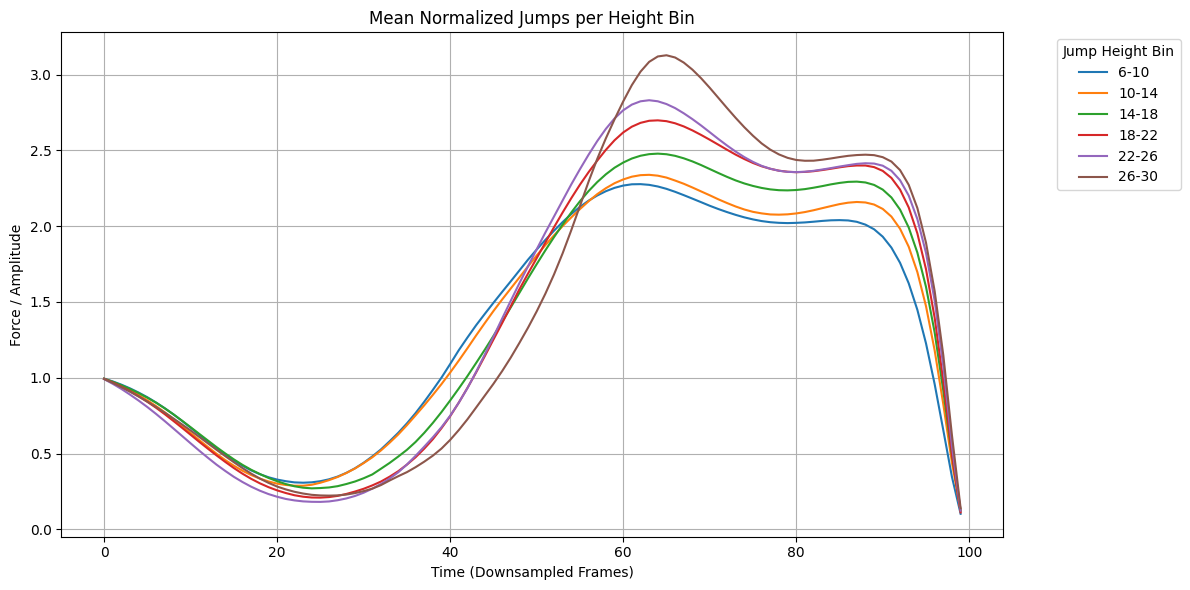

In [82]:
import matplotlib.pyplot as plt

BIN_SIZE = 4
MAX_JUMPS_PER_BIN = 120

fig, ax = plt.subplots(figsize=(12, 6))

for bin_label in bin_labels:
    group = binned_data[binned_data["jump_bin"] == bin_label]
    if group.empty:
        continue

    group_sample = group.sample(n=min(MAX_JUMPS_PER_BIN, len(group)), random_state=42)

    try:
        jump_matrix = np.stack(group_sample["downsampled_time_series"].values)
        mean_jump = jump_matrix.mean(axis=0)
        ax.plot(mean_jump, label=str(bin_label))
    except Exception as e:
        print(f"Skipping {bin_label}: {e}")

ax.set_title("Mean Normalized Jumps per Height Bin")
ax.set_xlabel("Time (Downsampled Frames)")
ax.set_ylabel("Force / Amplitude")
ax.legend(title="Jump Height Bin", bbox_to_anchor=(1.05, 1), loc='upper left')
ax.grid(True)
plt.tight_layout()
plt.show()


### Plotting Jump Heights of Closest to Mean Latent Space of Each Bin

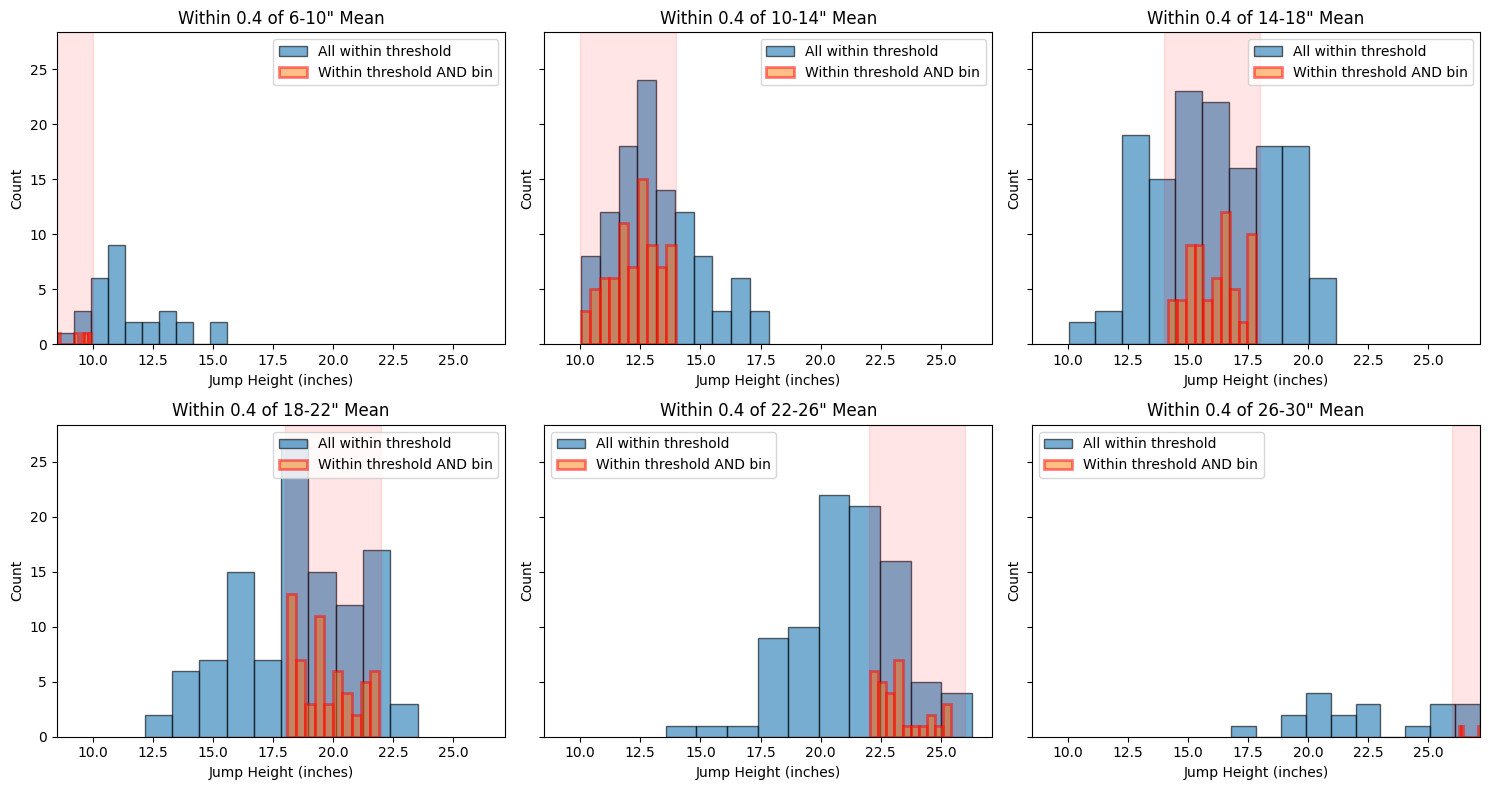

In [83]:
from collections import defaultdict

distance_threshold = 0.4

closest_heights_per_bin = defaultdict(list)
overlapping_heights_per_bin = defaultdict(list)

all_latents = np.stack(binned_data["vae_latent_space_4d"].values)
all_heights = binned_data["JUMP_HEIGHT_INCHES"].values
all_bins = binned_data["jump_bin"].values

# Group jumps by bin
for bin_label in sorted(binned_data["jump_bin"].unique(), key=lambda x: int(x.split('-')[0])):
    group = binned_data[binned_data["jump_bin"] == bin_label]
    if group.empty:
        continue

    bin_latents = np.stack(group["vae_latent_space_4d"].values)
    mean_vector = bin_latents.mean(axis=0)

    distances = np.linalg.norm(all_latents - mean_vector, axis=1)
    within_threshold = distances < distance_threshold

    closest_heights_per_bin[bin_label] = all_heights[within_threshold]

    mask_in_bin = all_bins == bin_label
    overlap_mask = within_threshold & mask_in_bin
    overlapping_heights_per_bin[bin_label] = all_heights[overlap_mask]

# Determine overall plot limits
all_closest_heights = np.concatenate(list(closest_heights_per_bin.values()))
x_min, x_max = all_closest_heights.min(), all_closest_heights.max()

# Setup subplots
n_bins = len(closest_heights_per_bin)
ncols = 3
nrows = int(np.ceil(n_bins / ncols))

fig, axs = plt.subplots(nrows, ncols, figsize=(15, 4 * nrows), sharey=True)
axs = axs.flatten()

# Iterate over the bins and plot histograms
for i, bin_label in enumerate(closest_heights_per_bin):
    heights = closest_heights_per_bin[bin_label]
    overlapping_heights = overlapping_heights_per_bin[bin_label]

    # Plot all heights within the distance threshold
    axs[i].hist(heights, bins=10, edgecolor='black', alpha=0.6, label='All within threshold')
    
    # Plot overlapping heights (within threshold and bin)
    if len(overlapping_heights) > 0:
        axs[i].hist(overlapping_heights, bins=10, edgecolor='red', alpha=0.5, linewidth=2, label='Within threshold AND bin')

    # Parse the bin_label to get the range to shade
    try:
        bin_start, bin_end = map(int, bin_label.split('-'))
        axs[i].axvspan(bin_start, bin_end, color='red', alpha=0.1)  # Shade the range for the current bin
    except ValueError:
        pass  # Handle case if bin_label is not in expected format

    # Set title, labels, and axis limits
    axs[i].set_title(f'Within {distance_threshold} of {bin_label}" Mean')
    axs[i].set_xlabel("Jump Height (inches)")
    axs[i].set_ylabel("Count")
    axs[i].set_xlim(x_min, x_max)
    axs[i].legend()

# Remove any extra subplots
for j in range(i + 1, len(axs)):
    fig.delaxes(axs[j])

plt.tight_layout()
plt.show()


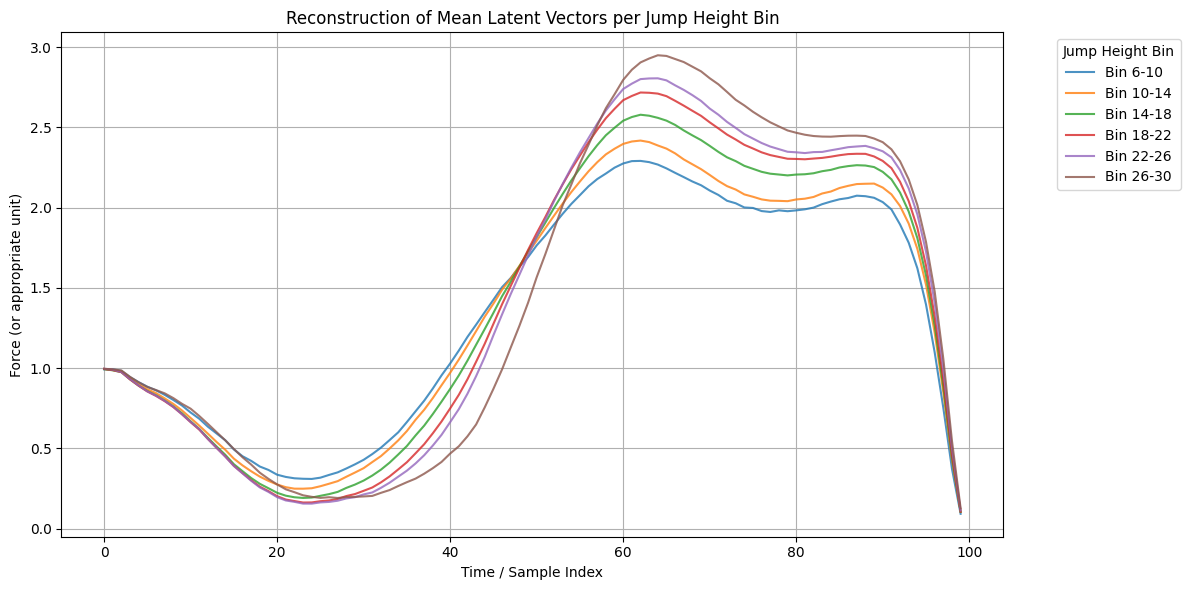

In [84]:

bin_mean_reconstructions = {}

for idx, label in enumerate(labels):
    group = binned_data[binned_data["jump_bin"] == label]
    latent_matrix = np.stack(group["vae_latent_space_4d"].values)
    bin_mean = torch.tensor(latent_matrix.mean(axis=0)).float()  # (4,) tensor
    reconstruction = vae.decode(bin_mean.unsqueeze(0)).detach().cpu().numpy()[0]
    bin_mean_reconstructions[label] = reconstruction
plt.figure(figsize=(12, 6))

for label, recon in bin_mean_reconstructions.items():
    plt.plot(recon, label=f'Bin {label}', alpha=0.8)

plt.title("Reconstruction of Mean Latent Vectors per Jump Height Bin")
plt.xlabel("Time / Sample Index")
plt.ylabel("Force (or appropriate unit)")
plt.legend(title="Jump Height Bin", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.grid(True)
plt.savefig("bin_mean_reconstructions.png", dpi=300)
plt.show()


Average Jump End Time for 26-30 bin: 0.39

Outliers with jump end times:
    JUMP_HEIGHT_INCHES jump_bin  jump_end_time
31           16.799689    14-18          0.376

Average jump height for all jumps within 0.4 of '26-30' mean (i.e. the ones plotted): 22.68 inches


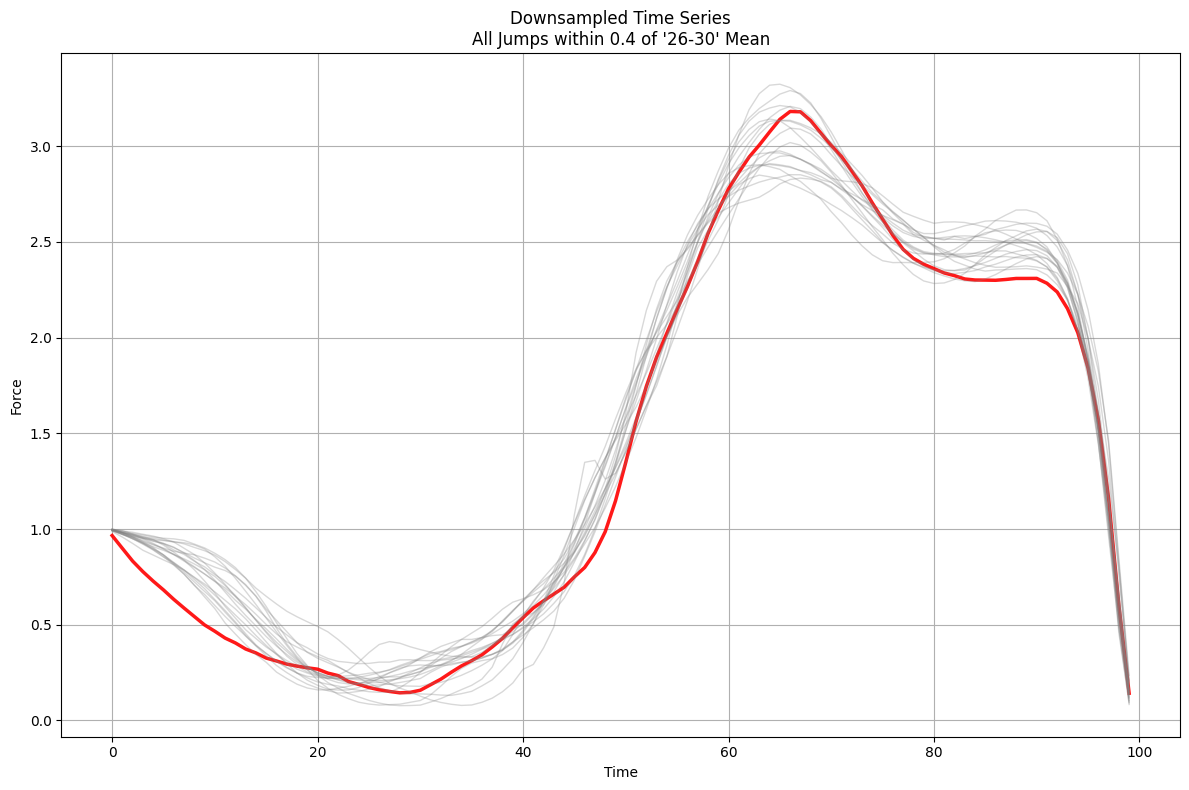

19


In [85]:
from scipy.spatial.distance import euclidean

target_bin = "26-30"
suspicious_height_threshold = 17.5  

group = binned_data[binned_data["jump_bin"] == target_bin]

average_jump_end_time = group["jump_end_time"].mean()
print(f"Average Jump End Time for {target_bin} bin: {average_jump_end_time:.2f}")

bin_latents = np.stack(group["vae_latent_space_4d"].values)
mean_vector = bin_latents.mean(axis=0)

distances = np.array([euclidean(vec, mean_vector) for vec in all_latents])

within_threshold = distances < distance_threshold
mask_in_bin = all_bins == target_bin
overlap_mask = within_threshold & mask_in_bin

suspicious_mask = within_threshold & (all_heights < suspicious_height_threshold)
suspicious_indices = np.where(suspicious_mask)[0]

outlier_info = binned_data.iloc[suspicious_indices][["JUMP_HEIGHT_INCHES", "jump_bin", "jump_end_time"]]
print("\nOutliers with jump end times:")
print(outlier_info)

plotted_heights = all_heights[within_threshold]
average_plotted_height = plotted_heights.mean()

print(f"\nAverage jump height for all jumps within {distance_threshold} of '{target_bin}' mean (i.e. the ones plotted): {average_plotted_height:.2f} inches")

plt.figure(figsize=(12, 8))

for idx, height in zip(np.where(within_threshold)[0], all_heights[np.where(within_threshold)[0]]):
    time_series = binned_data.iloc[idx]["downsampled_time_series"]
    
    if height < 17.5:
        plt.plot(time_series, color='red', linewidth=2.5, alpha=0.9)
    else:
        plt.plot(time_series, color='gray', linewidth=1, alpha=0.3)

plt.title(f"Downsampled Time Series\nAll Jumps within {distance_threshold} of '{target_bin}' Mean")
plt.xlabel("Time")
plt.ylabel("Force")
plt.grid(True)

plt.tight_layout()
plt.show()
print(len(plotted_heights))

Average Jump End Time for 22-26 bin: 0.39

Outliers with jump end times:
Empty DataFrame
Columns: [JUMP_HEIGHT_INCHES, jump_bin, jump_end_time]
Index: []

Average jump height for all jumps within 0.4 of '22-26' mean (i.e. the ones plotted): 21.21 inches


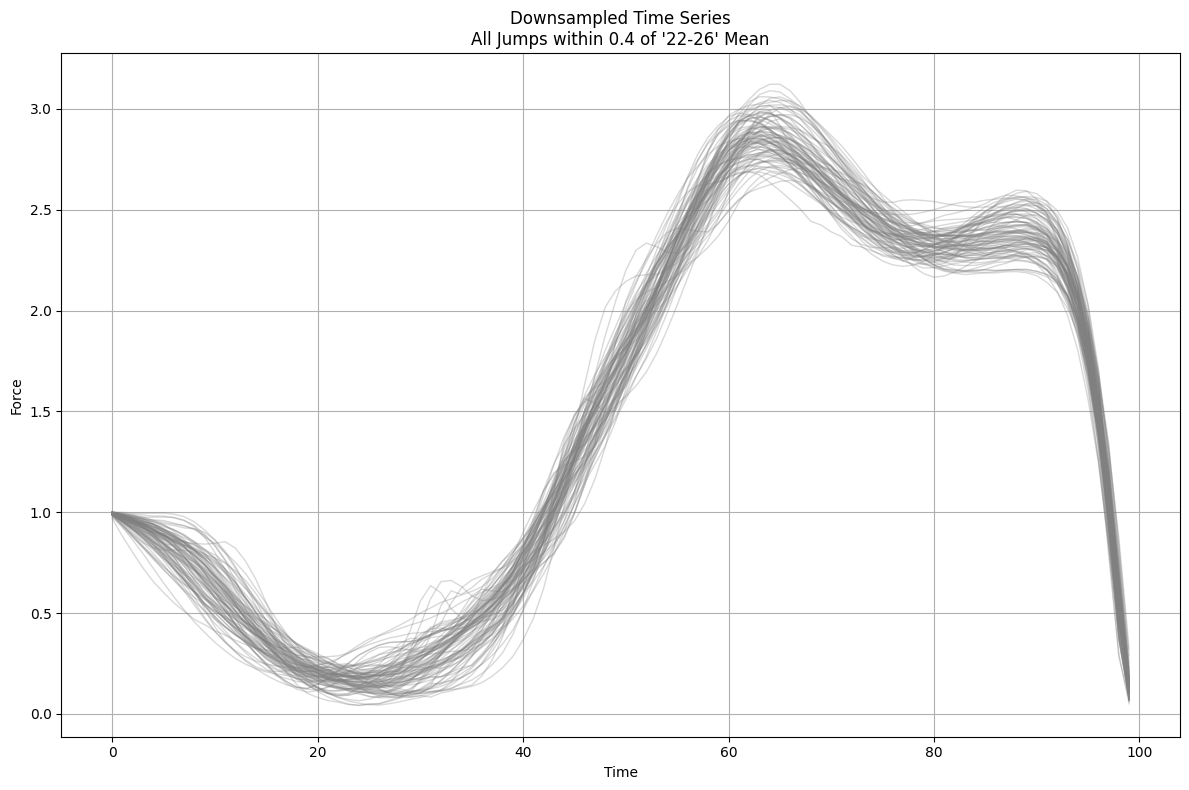

In [86]:
target_bin = "22-26"
suspicious_height_threshold = 13  

group = binned_data[binned_data["jump_bin"] == target_bin]

average_jump_end_time = group["jump_end_time"].mean()
print(f"Average Jump End Time for {target_bin} bin: {average_jump_end_time:.2f}")

bin_latents = np.stack(group["vae_latent_space_4d"].values)
mean_vector = bin_latents.mean(axis=0)

distances = np.linalg.norm(all_latents - mean_vector, axis=1)
within_threshold = distances < distance_threshold
mask_in_bin = all_bins == target_bin
overlap_mask = within_threshold & mask_in_bin

suspicious_mask = within_threshold & (all_heights < suspicious_height_threshold)
suspicious_indices = np.where(suspicious_mask)[0]

outlier_info = binned_data.iloc[suspicious_indices][["JUMP_HEIGHT_INCHES", "jump_bin", "jump_end_time"]]
print("\nOutliers with jump end times:")
print(outlier_info)

plotted_heights = all_heights[within_threshold]
average_plotted_height = plotted_heights.mean()

print(f"\nAverage jump height for all jumps within {distance_threshold} of '{target_bin}' mean (i.e. the ones plotted): {average_plotted_height:.2f} inches")


plt.figure(figsize=(12, 8))

for idx, height in zip(np.where(within_threshold)[0], all_heights[np.where(within_threshold)[0]]):
    time_series = binned_data.iloc[idx]["downsampled_time_series"]
    
    if height < suspicious_height_threshold:
        plt.plot(time_series, color='red', linewidth=2.5, alpha=0.9)
    else:
        plt.plot(time_series, color='gray', linewidth=1, alpha=0.3)

plt.title(f"Downsampled Time Series\nAll Jumps within {distance_threshold} of '{target_bin}' Mean")
plt.xlabel("Time")
plt.ylabel("Force")
plt.grid(True)

plt.tight_layout()
plt.show()


Average Jump End Time for 18-22 bin: 0.41

Outliers with jump end times:
Empty DataFrame
Columns: [JUMP_HEIGHT_INCHES, jump_bin, jump_end_time]
Index: []

Average jump height for all jumps within 0.4 of '18-22' mean (i.e. the ones plotted): 18.49 inches


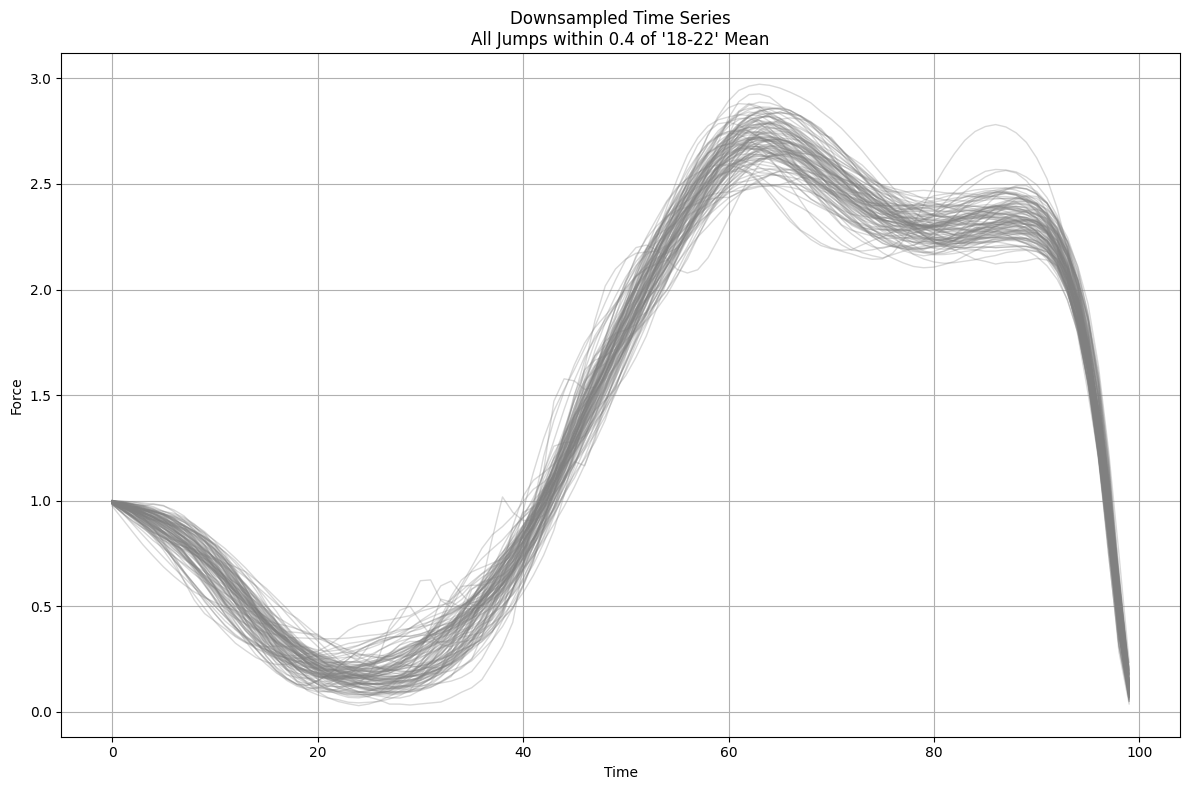

In [87]:
target_bin = "18-22"
suspicious_height_threshold = 11 

group = binned_data[binned_data["jump_bin"] == target_bin]

average_jump_end_time = group["jump_end_time"].mean()
print(f"Average Jump End Time for {target_bin} bin: {average_jump_end_time:.2f}")

bin_latents = np.stack(group["vae_latent_space_4d"].values)
mean_vector = bin_latents.mean(axis=0)

distances = np.linalg.norm(all_latents - mean_vector, axis=1)
within_threshold = distances < distance_threshold
mask_in_bin = all_bins == target_bin
overlap_mask = within_threshold & mask_in_bin

suspicious_mask = within_threshold & (all_heights < suspicious_height_threshold)
suspicious_indices = np.where(suspicious_mask)[0]

outlier_info = binned_data.iloc[suspicious_indices][["JUMP_HEIGHT_INCHES", "jump_bin", "jump_end_time"]]
print("\nOutliers with jump end times:")
print(outlier_info)
plotted_heights = all_heights[within_threshold]
average_plotted_height = plotted_heights.mean()

print(f"\nAverage jump height for all jumps within {distance_threshold} of '{target_bin}' mean (i.e. the ones plotted): {average_plotted_height:.2f} inches")


# Plot time series
plt.figure(figsize=(12, 8))

for idx, height in zip(np.where(within_threshold)[0], all_heights[np.where(within_threshold)[0]]):
    time_series = binned_data.iloc[idx]["downsampled_time_series"]
    
    if height < suspicious_height_threshold:
        plt.plot(time_series, color='red', linewidth=2.5, alpha=0.9)
    else:
        plt.plot(time_series, color='gray', linewidth=1, alpha=0.3)

plt.title(f"Downsampled Time Series\nAll Jumps within {distance_threshold} of '{target_bin}' Mean")
plt.xlabel("Time")
plt.ylabel("Force")
plt.grid(True)

plt.tight_layout()
plt.show()


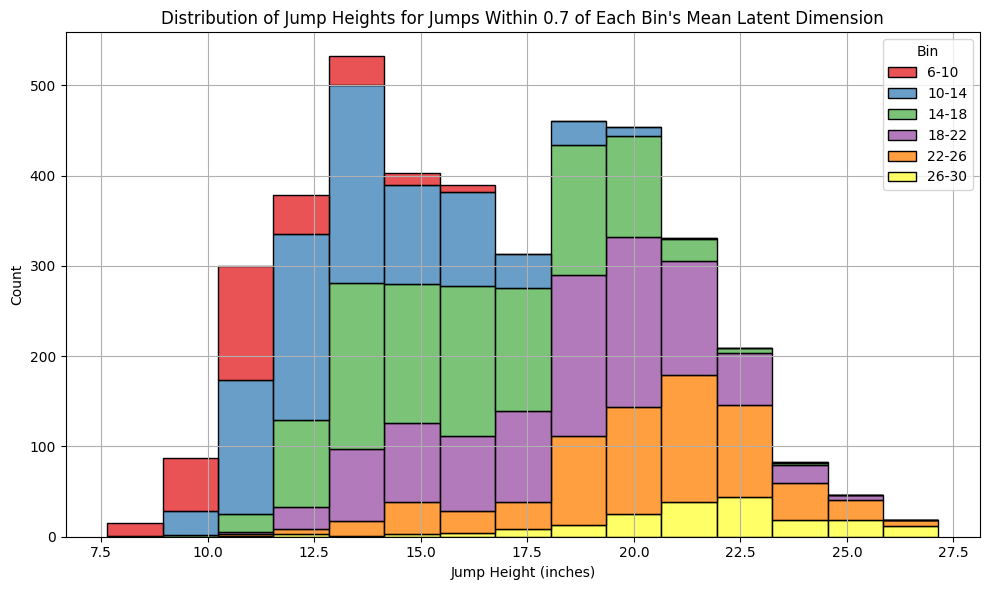

In [90]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict

distance_threshold = 0.7

# Data structures for storing heights within threshold per bin
all_latents = np.stack(binned_data["vae_latent_space_4d"].values)
all_heights = binned_data["JUMP_HEIGHT_INCHES"].values
all_bins = binned_data["jump_bin"].values

# Store heights within the threshold for each bin
heights_within_threshold = []
bin_labels = []

for bin_label in sorted(binned_data["jump_bin"].unique(), key=lambda x: int(x.split('-')[0])):
    group = binned_data[binned_data["jump_bin"] == bin_label]
    if group.empty:
        continue

    bin_latents = np.stack(group["vae_latent_space_4d"].values)
    mean_vector = bin_latents.mean(axis=0)

    distances = np.linalg.norm(all_latents - mean_vector, axis=1)
    within_threshold = distances < distance_threshold

    heights_within_threshold.extend(all_heights[within_threshold])
    bin_labels.extend([bin_label] * len(all_heights[within_threshold]))

# Create a DataFrame for seaborn plotting
import pandas as pd
data = pd.DataFrame({
    "Jump Height (inches)": heights_within_threshold,
    "Bin": bin_labels
})

# Plotting with seaborn
plt.figure(figsize=(10, 6))
sns.histplot(data=data, x="Jump Height (inches)", hue="Bin", multiple="stack", bins=15, palette="Set1")

plt.title(f"Distribution of Jump Heights for Jumps Within {distance_threshold} of Each Bin's Mean Latent Dimension")
plt.xlabel("Jump Height (inches)")
plt.ylabel("Count")
plt.grid(True)
plt.tight_layout()
plt.show()


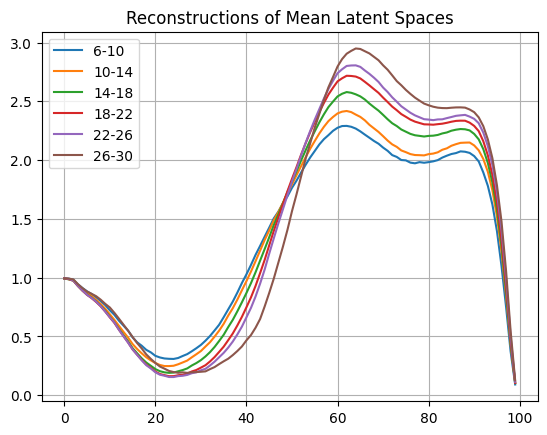

In [89]:
mean_reconstructions = {}
# mean_tensor = torch.tensor(np.mean(data["vae_latent_space_4d"])).float()

i = 0
ls_names = ["6-10", "10-14", "14-18", "18-22", "22-26", "26-30"]
for l in sample_means:
    l = torch.tensor(l).float()
    mean_reconstructions[ls_names[i]] = vae.decode(l.unsqueeze(0)).detach().cpu().numpy()[0]
    i+= 1

for key in mean_reconstructions:
    plt.plot(mean_reconstructions[key], label=str(key))
plt.title("Reconstructions of Mean Latent Spaces")
plt.legend()
plt.grid()

In [38]:
data.head(1)

,Jump Height (inches),Bin
0,12.849807,6-10


Reference Jump:
Height: 28.614005535286005
Jump Duration: 0.392

Most Similar Jumps:
- Height: 26.00, Duration: 0.375s
- Height: 27.88, Duration: 0.400s
- Height: 27.58, Duration: 0.381s
- Height: 25.30, Duration: 0.395s
- Height: 15.79, Duration: 0.359s


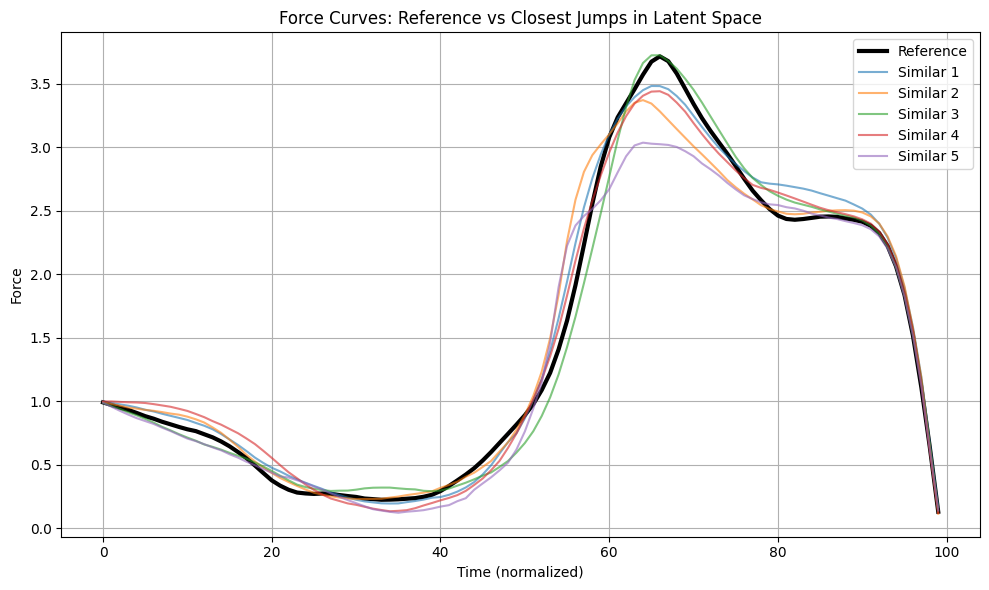

In [39]:
ref_idx = np.argmax(all_heights)
ref_latent = all_latents[ref_idx]
from scipy.spatial.distance import cdist

# Reshape needed for 2D input to cdist
distances = cdist([ref_latent], all_latents, metric='euclidean').flatten()
closest_indices = np.argsort(distances)[1:6]  # Exclude self, get top 5
print("Reference Jump:")
print("Height:", all_heights[ref_idx])
print("Jump Duration:", binned_data.iloc[ref_idx]["jump_end_time"])

print("\nMost Similar Jumps:")
for idx in closest_indices:
    print(f"- Height: {all_heights[idx]:.2f}, Duration: {binned_data.iloc[idx]['jump_end_time']:.3f}s")
plt.figure(figsize=(10, 6))

# Plot reference
plt.plot(binned_data.iloc[ref_idx]['downsampled_time_series'], label="Reference", color='black', linewidth=3)

# Plot similar ones
for i, idx in enumerate(closest_indices):
    plt.plot(binned_data.iloc[idx]['downsampled_time_series'], label=f"Similar {i+1}", alpha=0.6)

plt.title("Force Curves: Reference vs Closest Jumps in Latent Space")
plt.xlabel("Time (normalized)")
plt.ylabel("Force")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


Reference Jump:
Height: 6.047887869204115
Jump Duration: 0.584

Most Similar Jumps:
- Height: 10.12, Duration: 1.195s
- Height: 10.12, Duration: 1.195s
- Height: 11.31, Duration: 0.635s
- Height: 9.26, Duration: 1.122s
- Height: 6.71, Duration: 0.983s


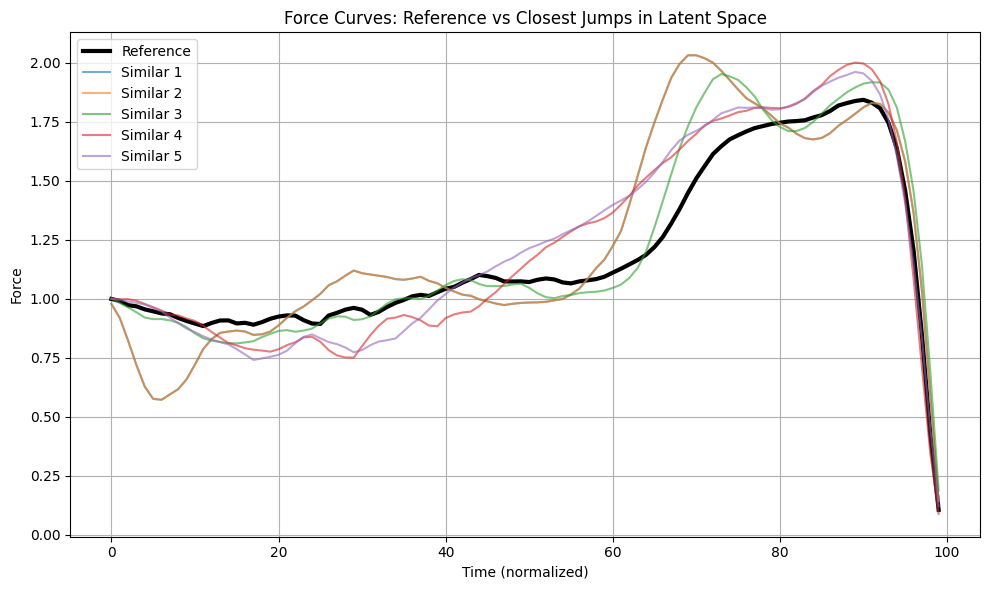

In [40]:
ref_idx = np.argmin(all_heights)
ref_latent = all_latents[ref_idx]
from scipy.spatial.distance import cdist

distances = cdist([ref_latent], all_latents, metric='euclidean').flatten()
closest_indices = np.argsort(distances)[1:6]  
print("Reference Jump:")
print("Height:", all_heights[ref_idx])
print("Jump Duration:", binned_data.iloc[ref_idx]["jump_end_time"])

print("\nMost Similar Jumps:")
for idx in closest_indices:
    print(f"- Height: {all_heights[idx]:.2f}, Duration: {binned_data.iloc[idx]['jump_end_time']:.3f}s")
plt.figure(figsize=(10, 6))

plt.plot(binned_data.iloc[ref_idx]['downsampled_time_series'], label="Reference", color='black', linewidth=3)

for i, idx in enumerate(closest_indices):
    plt.plot(binned_data.iloc[idx]['downsampled_time_series'], label=f"Similar {i+1}", alpha=0.6)

plt.title("Force Curves: Reference vs Closest Jumps in Latent Space")
plt.xlabel("Time (normalized)")
plt.ylabel("Force")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [41]:
data = binned_data

In [42]:
np.mean(bootstrap_spreads)

1.3049266

In [43]:
# differences in latent space between mean for bin, and each jump in that bin, 
from scipy.spatial.distance import euclidean

bin_spreads = []
bin_midpoints = []

for i, label in enumerate(bin_labels):
    group = binned_data[binned_data["jump_bin"] == label]
    if group.empty:
        continue

    latent_matrix = np.stack(group["vae_latent_space_4d"].values)
    mean_vector = latent_matrix.mean(axis=0)
    distances = [euclidean(vec, mean_vector) for vec in latent_matrix]
    avg_distance = np.mean(distances)

    bin_spreads.append(avg_distance)
    bin_midpoints.append((bins[i] + bins[i+1]) / 2)

plt.figure(figsize=(8, 5))
plt.plot(bin_midpoints, bin_spreads, marker='o')
plt.xlabel("Jump Height Bin Midpoint (inches)")
plt.ylabel("Avg Distance to Bin Mean in Latent Space")
plt.title("Jump Shape Consistency vs. Jump Height")
plt.grid(True)
plt.tight_layout()
plt.show()


IndexError: index 7 is out of bounds for axis 0 with size 7

In [ ]:
# plt.figure(figsize=(8, 6))
# plt.scatter(latent_2d_sample[:, 0], latent_2d_sample[:, 1], c=cluster_labels_sample, cmap='tab10')
# plt.title("t-SNE of Latent Space (colored by KMeans cluster) - Sampled Data")
# plt.xlabel("t-SNE 1")
# plt.ylabel("t-SNE 2")
# plt.colorbar(label='Cluster ID')
# plt.grid(True)
# plt.show()

In [ ]:
samples_per_cluster = 10
plt.figure(figsize=(12, 8))
unique_clusters = np.unique(cluster_labels_sample)
cols = 2
rows = len(unique_clusters) // cols + (len(unique_clusters) % cols > 0)

for cluster in unique_clusters:
    cluster_indices = np.where(cluster_labels_sample == cluster)[0]
    
    selected_indices = np.random.choice(cluster_indices, size=min(samples_per_cluster, len(cluster_indices)), replace=False)
    
    plt.subplot(rows, cols, cluster + 1)
    
    for i, idx in enumerate(selected_indices):
        latent_vector = latent_4d_sample[idx]
        
        reconstructed_jump = vae.decode(torch.tensor(latent_vector).unsqueeze(0).float()).detach().cpu().numpy()[0]
        
        plt.plot(reconstructed_jump, label=f"Sample {i + 1}")
    
    plt.title(f"Cluster {cluster}")
    plt.xlabel("Time")
    plt.ylabel("Jump Height")
    plt.grid(True)
    # plt.legend()

plt.tight_layout()
plt.show()

### Colored by Jump Height/Sport

In [ ]:
sample_data = data.sample(frac=0.3, random_state=42)

latent_4d_sample = np.stack(sample_data["vae_latent_space_4d"].values)

tsne = TSNE(n_components=2, perplexity=30, random_state=42)
latent_2d_sample = tsne.fit_transform(latent_4d_sample)

plt.figure(figsize=(8, 6))
plt.scatter(latent_2d_sample[:, 0], latent_2d_sample[:, 1],
            c=sample_data["JUMP_HEIGHT_INCHES"], cmap='viridis')
plt.colorbar(label="Jump Height (inches)")
plt.xlabel("t-SNE Dimension 1")
plt.ylabel("t-SNE Dimension 2")
plt.title("t-SNE of VAE Latent Space Colored by Jump Height")
plt.grid(True)
plt.show()


In [ ]:
teams = sample_data["Team"].astype(str)  
unique_teams = teams.unique()
palette = sns.color_palette("tab10", len(unique_teams))
team_to_color = {team: palette[i] for i, team in enumerate(unique_teams)}
colors = teams.map(team_to_color)

plt.figure(figsize=(10, 7))
scatter = plt.scatter(latent_2d_sample[:, 0], latent_2d_sample[:, 1],
                      c=colors, alpha=0.8)
plt.xlabel("t-SNE Dimension 1")
plt.ylabel("t-SNE Dimension 2")
plt.title("t-SNE of VAE Latent Space Colored by Sport")
plt.grid(True)

from matplotlib.lines import Line2D
legend_elements = [Line2D([0], [0], marker='o', color='w', label=team,
                          markerfacecolor=color, markersize=8)
                   for team, color in team_to_color.items()]
plt.legend(handles=legend_elements, title="Team", bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()


In [ ]:
filtered_data = data[data["Team"].isin(["Football", "Men's Basketball"])].sample(frac=0.5, random_state=42)

latent_4d_sample = np.stack(filtered_data["vae_latent_space_4d"].values)

tsne = TSNE(n_components=2, perplexity=30, random_state=42)
latent_2d_sample = tsne.fit_transform(latent_4d_sample)

plt.figure(figsize=(8, 6))
plt.scatter(latent_2d_sample[:, 0], latent_2d_sample[:, 1],
            c=filtered_data["JUMP_HEIGHT_INCHES"], cmap='viridis')
plt.colorbar(label="Jump Height (inches)")
plt.xlabel("t-SNE Dimension 1")
plt.ylabel("t-SNE Dimension 2")
plt.title("t-SNE of VAE Latent Space (Football & Men's Basketball)")
plt.grid(True)
plt.show()


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

fig, ax = plt.subplots(figsize=(8, 6))

sc = ax.scatter(latent_2d_sample[:, 0], latent_2d_sample[:, 1],
                c=filtered_data["JUMP_HEIGHT_INCHES"], cmap='viridis', alpha=0.8)
ax.set_xlabel("t-SNE Dimension 1")
ax.set_ylabel("t-SNE Dimension 2")
ax.set_title("Preview of t-SNE: Choose Region")
ax.grid(True)
plt.colorbar(sc, ax=ax, label="Jump Height (inches)")
plt.show()

x_min = float(input("Enter x_min: "))
x_max = float(input("Enter x_max: "))
y_min = float(input("Enter y_min: "))
y_max = float(input("Enter y_max: "))

x = latent_2d_sample[:, 0]
y = latent_2d_sample[:, 1]
mask = (x >= x_min) & (x <= x_max) & (y >= y_min) & (y <= y_max)

selected_latents = latent_4d_sample[mask]
selected_heights = filtered_data["JUMP_HEIGHT_INCHES"].values[mask]

with torch.no_grad():
    latent_tensor = torch.tensor(selected_latents).float()
    reconstructions = vae.decode(latent_tensor).cpu().numpy()

fig, axs = plt.subplots(1, 2, figsize=(14, 6))

sc = axs[0].scatter(x, y, c=filtered_data["JUMP_HEIGHT_INCHES"], cmap='viridis', alpha=0.8)
axs[0].set_xlabel("t-SNE Dimension 1")
axs[0].set_ylabel("t-SNE Dimension 2")
axs[0].set_title("t-SNE of VAE Latent Space (Football & Men's Basketball)")
axs[0].grid(True)
plt.colorbar(sc, ax=axs[0], label="Jump Height (inches)")

rect = patches.Rectangle((x_min, y_min), x_max - x_min, y_max - y_min,
                         linewidth=2, edgecolor='red', facecolor='none')
axs[0].add_patch(rect)

for i in range(min(5, len(reconstructions))):
    height = selected_heights[i]
    axs[1].plot(reconstructions[i], label=f"Sample {i+1} ({height:.1f} in)")

axs[1].set_title("Reconstructed Jumps from Selected Region")
axs[1].set_xlabel("Time")
axs[1].set_ylabel("Force")
axs[1].grid(True)
axs[1].legend()

plt.tight_layout()
plt.show()


In [ ]:
data.head(1)

In [ ]:
from sklearn.metrics.pairwise import euclidean_distances

data["recordedUTC"] = pd.to_datetime(data["recordedUTC"])
data["Year"] = data["recordedUTC"].dt.year

first_year = data.groupby("profileID")["Year"].transform("min") # take first year for athlete based on year in recordedUTC, that represents year 1
data["Rel_year"] = data["Year"] - first_year + 1  

vae_latents = np.stack(data["vae_latent_space_4d"].values)
data["vae_latent_array"] = list(vae_latents)  

mean_latents = (
    data.groupby(["profileID", "Rel_year"])["vae_latent_array"]
    .apply(lambda x: np.mean(np.stack(x), axis=0))
)

def get_mean_latent(row):
    return mean_latents.loc[(row["profileID"], row["Rel_year"])]

data["mean_vae_latent"] = data.apply(get_mean_latent, axis=1)

data["VAE_YEARLY_DIST"] = data.apply(
    lambda row: np.linalg.norm(row["vae_latent_array"] - row["mean_vae_latent"]), axis=1 # take euclidean distance from each jump of the year, and the mean latent space jump for year
)


In [ ]:
yearly_consistency = (
    data.groupby(["profileID", "Team", "Rel_year"])[["VAE_YEARLY_DIST", "JUMP_HEIGHT_INCHES"]]
    .mean()
    .reset_index()
)


In [ ]:
yearly_consistency

In [ ]:
yearly_consistency = (
    data.groupby(["profileID", "Rel_year"])["VAE_YEARLY_DIST"]
    .mean()
    .reset_index(name="Avg_VAE_Yearly_Dist")
)


In [ ]:
import matplotlib.pyplot as plt

avg_consistency_per_year = (
    yearly_consistency.groupby("Rel_year")["Avg_VAE_Yearly_Dist"]
    .mean()
    .reset_index()
)

# Plot
plt.figure(figsize=(10, 6))
plt.plot(avg_consistency_per_year["Rel_year"], avg_consistency_per_year["Avg_VAE_Yearly_Dist"], marker='o')
plt.title("Average Latent Space Deviation Over Time (All Athletes)")
plt.xlabel("Relative Year")
plt.ylabel("Avg VAE Yearly Distance")
plt.grid(True)
plt.xticks(avg_consistency_per_year["Rel_year"])
plt.show()


In [ ]:
plt.figure(figsize=(12, 7))

for pid, group in yearly_consistency.groupby("profileID"):
    group = group.sort_values("Rel_year")
    x_vals = group["Rel_year"].values
    y_vals = group["Avg_VAE_Yearly_Dist"].values

    for i in range(len(x_vals) - 1):
        x_segment = [x_vals[i], x_vals[i+1]]
        y_segment = [y_vals[i], y_vals[i+1]]

        color = "green" if y_segment[1] < y_segment[0] else "red"
        plt.plot(x_segment, y_segment, color=color, alpha=0.6)

plt.plot(
    avg_consistency_per_year["Rel_year"],
    avg_consistency_per_year["Avg_VAE_Yearly_Dist"],
    color="blue",
    linewidth=3,
    label="Average Trend"
)

plt.title("Year-to-Year Changes in Consistency (Latent Deviation)")
plt.xlabel("Relative Year")
plt.ylabel("Avg VAE Yearly Distance")
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
complete_profiles = yearly_consistency.groupby("profileID").filter(lambda x: len(x["Rel_year"].unique()) == 4)

plt.figure(figsize=(12, 7))

for pid, group in complete_profiles.groupby("profileID"):
    group = group.sort_values("Rel_year")
    x_vals = group["Rel_year"].values
    y_vals = group["Avg_VAE_Yearly_Dist"].values

    for i in range(len(x_vals) - 1):
        x_segment = [x_vals[i], x_vals[i+1]]
        y_segment = [y_vals[i], y_vals[i+1]]

        color = "green" if y_segment[1] < y_segment[0] else "red"
        plt.plot(x_segment, y_segment, color=color, alpha=0.6)

# plt.plot(
#     avg_consistency_per_year["Rel_year"],
#     avg_consistency_per_year["Avg_VAE_Yearly_Dist"],
#     color="blue",
#     linewidth=3,
#     label="Average Trend"
# )

plt.title("Year-to-Year Changes in Consistency (Latent Deviation) — Profiles with 4 Years")
plt.xlabel("Relative Year")
plt.ylabel("Avg VAE Yearly Distance")
# plt.legend()
plt.grid(True)
plt.show()


In [ ]:
data.head(1)

In [ ]:
team_consistency = yearly_consistency.groupby("Team")["Avg_VAE_Yearly_Dist"].mean()

In [ ]:
team_consistency = yearly_consistency.groupby("Team")["Avg_VAE_Yearly_Dist"].mean()

In [ ]:
team_consistency

In [ ]:
import matplotlib.pyplot as plt


sorted_teams = dict(sorted(team_consistency.items(), key=lambda item: item[1], reverse=False))

plt.figure(figsize=(10, 8))
plt.barh(list(sorted_teams.keys()), list(sorted_teams.values()))
plt.xlabel('Average Variation in Latent Space')
plt.title('Team Variation Scores')
plt.gca().invert_yaxis()  
plt.tight_layout()
plt.show()


In [ ]:
def get_trend_flags(df):
    df = df.sort_values("Rel_year").copy()
    trends = [None]  # First year has no previous year to compare

    for i in range(1, len(df)):
        prev = df.iloc[i - 1]["Avg_VAE_Yearly_Dist"]
        curr = df.iloc[i]["Avg_VAE_Yearly_Dist"]

        if curr < prev:
            trends.append("Improved")
        else:
            trends.append("Worsened")

    df["yearly_consistency_trend"] = trends
    return df

# Apply to each athlete
yearly_consistency = yearly_consistency.groupby("profileID").apply(get_trend_flags).reset_index(drop=True)


In [ ]:
len(yearly_consistency[yearly_consistency["yearly_consistency_trend"] == "Worsened"])

In [ ]:
yearly_consistency

In [ ]:
from sklearn.linear_model import LinearRegression

athlete_slopes = []

for pid, group in yearly_consistency.groupby("profileID"):
    group = group.sort_values("Rel_year")
    x = group["Rel_year"].values.reshape(-1, 1)
    y = group["Avg_VAE_Yearly_Dist"].values

    if len(x) < 2:
        continue

    model = LinearRegression().fit(x, y)
    slope = model.coef_[0]
    athlete_slopes.append((pid, slope))

chaotic_profiles = sorted(athlete_slopes, key=lambda x: x[1], reverse=True)[:5]
chaotic_ids = [pid for pid, _ in chaotic_profiles]


In [ ]:
chaotic_data = data[data["profileID"].isin(chaotic_ids)]

fig, axs = plt.subplots(len(chaotic_ids), 1, figsize=(10, 4 * len(chaotic_ids)))

for i, pid in enumerate(chaotic_ids):
    athlete_jumps = chaotic_data[chaotic_data["profileID"] == pid]
    jump_subset = athlete_jumps.sample(n=min(3, len(athlete_jumps)), random_state=42)

    latents = np.stack(jump_subset["vae_latent_space_4d"].values)
    heights = jump_subset["JUMP_HEIGHT_INCHES"].values

    with torch.no_grad():
        latent_tensor = torch.tensor(latents).float()
        reconstructions = vae.decode(latent_tensor).cpu().numpy()

    for j in range(len(reconstructions)):
        axs[i].plot(reconstructions[j], label=f"Jump {j+1} ({heights[j]:.1f}\" high)")

    axs[i].set_title(f"Athlete {pid} – Sampled Reconstructed Jumps")
    axs[i].set_xlabel("Time")
    axs[i].set_ylabel("Force")
    axs[i].legend()
    axs[i].grid(True)

plt.tight_layout()
plt.show()


In [ ]:
# Threshold for "near perfect consistency"
threshold = 0.05  # Adjust as needed depending on your scale

# Find athletes who ever reach below this value
athletes_near_zero = yearly_consistency[
    yearly_consistency["Avg_VAE_Yearly_Dist"] < threshold
]["profileID"].unique()

print(f"Number of athletes with consistency ~0: {len(athletes_near_zero)}")


In [ ]:
from sklearn.linear_model import LinearRegression

slopes = []

for pid, group in yearly_consistency.groupby("profileID"):
    if group["Rel_year"].nunique() >= 2:
        X = group["Rel_year"].values.reshape(-1, 1)
        y = group["Avg_VAE_Yearly_Dist"].values
        model = LinearRegression().fit(X, y)
        slopes.append({
            "profileID": pid,
            "slope": model.coef_[0]
        })

slopes_df = pd.DataFrame(slopes)
import seaborn as sns

sns.histplot(slopes_df["slope"], bins=30, kde=True)
plt.title("Distribution of Athlete Consistency Trends (Slopes)")
plt.xlabel("Slope of Avg VAE Yearly Distance Over Time")
plt.grid(True)
plt.show()


In [ ]:
avg_jump_height_per_year = (
    data.groupby("Rel_year")["JUMP_HEIGHT_INCHES"]
    .mean()
    .reset_index()
)

combined_df = avg_consistency_per_year.merge(
    avg_jump_height_per_year, on="Rel_year", how="inner"
)

fig, ax1 = plt.subplots(figsize=(10, 6))

ax1.plot(combined_df["Rel_year"], combined_df["Avg_VAE_Yearly_Dist"], color='blue', marker='o', label='Latent Deviation')
ax1.set_xlabel("Relative Year")
ax1.set_ylabel("Avg VAE Yearly Distance", color='blue')
ax1.tick_params(axis='y', labelcolor='blue')
ax1.grid(True)

ax2 = ax1.twinx()
ax2.plot(combined_df["Rel_year"], combined_df["JUMP_HEIGHT_INCHES"], color='green', marker='s', label='Jump Height')
ax2.set_ylabel("Avg Jump Height (inches)", color='green')
ax2.tick_params(axis='y', labelcolor='green')

plt.title("Latent Deviation vs. Jump Height Over Time")
fig.tight_layout()
plt.xticks(combined_df["Rel_year"])
plt.show()

In [ ]:
data_sorted = data.sort_values(by=["profileID", "recordedUTC"])  


In [ ]:
def compute_path_length(latents):
    diffs = np.diff(latents, axis=0)
    distances = np.linalg.norm(diffs, axis=1)
    return distances.sum()

def compute_rate_of_change(latents, timestamps):
    if len(latents) < 2:
        return np.nan
    deltas = np.diff(latents, axis=0)
    time_deltas = np.diff(timestamps).astype('timedelta64[D]').astype(int)
    distances = np.linalg.norm(deltas, axis=1)
    rates = distances / (time_deltas + 1e-5)  
    return np.mean(rates)

def compute_angle_changes(latents):
    if len(latents) < 3:
        return np.nan
    diffs1 = np.diff(latents[:-1], axis=0)
    diffs2 = np.diff(latents[1:], axis=0)
    
    dot_products = np.sum(diffs1 * diffs2, axis=1)
    norms1 = np.linalg.norm(diffs1, axis=1)
    norms2 = np.linalg.norm(diffs2, axis=1)
    cos_angles = dot_products / (norms1 * norms2 + 1e-6)
    angles = np.arccos(np.clip(cos_angles, -1, 1))  
    return np.mean(np.degrees(angles))

jump_counts = data_sorted["profileID"].value_counts()
valid_profiles = jump_counts[jump_counts >= 3].index

# Filter data_sorted before processing
filtered_data = data_sorted[data_sorted["profileID"].isin(valid_profiles)]

trajectory_metrics = []

for profile_id, group in filtered_data.groupby("profileID"):
    latents = np.stack(group["vae_latent_space_4d"].values)
    timestamps = group["recordedUTC"].values

    metrics = {
        "profileID": profile_id,
        "path_length": compute_path_length(latents),
        "rate_of_change": compute_rate_of_change(latents, timestamps),
        "angle_change": compute_angle_changes(latents),
    }
    trajectory_metrics.append(metrics)

trajectory_df = pd.DataFrame(trajectory_metrics)


In [ ]:
import seaborn as sns

sns.histplot(trajectory_df["path_length"], bins=20)
plt.title("Distribution of Latent Trajectory Path Lengths")
plt.show()

sns.scatterplot(data=trajectory_df, x="path_length", y="angle_change")
plt.title("Stable vs Chaotic Movers")
plt.xlabel("Path Length")
plt.ylabel("Mean Angle Change")
plt.grid(True)
plt.show()


In [ ]:
outliers = trajectory_df.sort_values("path_length", ascending=True).head(5)
chaotic_ids = outliers["profileID"].values
chaotic_data = data_sorted[data_sorted["profileID"].isin(chaotic_ids)]

from random import sample

fig, axs = plt.subplots(len(chaotic_ids), 1, figsize=(10, 4 * len(chaotic_ids)))

for i, pid in enumerate(chaotic_ids):
    athlete_jumps = chaotic_data[chaotic_data["profileID"] == pid]

    jump_subset = athlete_jumps.sample(n=min(3, len(athlete_jumps)), random_state=42)

    latents = np.stack(jump_subset["vae_latent_space_4d"].values)
    heights = jump_subset["JUMP_HEIGHT_INCHES"].values

    with torch.no_grad():
        latent_tensor = torch.tensor(latents).float()
        reconstructions = vae.decode(latent_tensor).cpu().numpy()

    for j in range(len(reconstructions)):
        axs[i].plot(reconstructions[j], label=f"Jump {j+1} ({heights[j]:.1f}\" high)")

    axs[i].set_title(f"Reconstructed Jumps — Athlete {pid}")
    axs[i].set_xlabel("Time")
    axs[i].set_ylabel("Force")
    axs[i].legend()
    axs[i].grid(True)

plt.tight_layout()
plt.show()


### Jump Variance Within Session
- Does jump height based on impulse momentum or flight time yield higher variance?

In [ ]:
session_variances = []

for session_id, athlete in data.groupby("testID"):
    if len(group) < 2:
        continue  
    
    var_inches = athlete["JUMP_HEIGHT_INCHES"].var()
    var_imp_mom = athlete["JUMP_HEIGHT_IMP_MOM"].var()
    
    session_variances.append({
        "session": session_id,
        "var_inches": var_inches,
        "var_imp_mom": var_imp_mom
    })

var_df = pd.DataFrame(session_variances)
var_df = var_df.dropna()


In [ ]:
# var_df

In [ ]:
import matplotlib.pyplot as plt

avg_var_inches = var_df["var_inches"].mean()
avg_var_imp_mom = var_df["var_imp_mom"].mean()

avg_variances = {
    "Jump Height (Flight-Time)": avg_var_inches,
    "Jump Height (Impulse-Momentum)": avg_var_imp_mom
}

plt.figure(figsize=(6, 5))
plt.bar(avg_variances.keys(), avg_variances.values(), color=["skyblue", "salmon"])
plt.ylabel("Average Variance")
plt.title("Average Variance in Jump Height Measurements")
plt.tight_layout()
plt.show()


In [ ]:
print("Flight Time (INCHES) — Avg Variance:", var_df["var_inches"].mean())
print("Impulse-Momentum — Avg Variance:", var_df["var_imp_mom"].mean())

print("\nFlight Time (INCHES) — Variance of Variance:", var_df["var_inches"].var())
print("Impulse-Momentum — Variance of Variance:", var_df["var_imp_mom"].var())


In [ ]:
from scipy.signal import find_peaks

def determine_modality(latent_vector_4d):
    latent_tensor = torch.tensor(latent_vector_4d).float().unsqueeze(0)
    
    reconstruction = vae.decode(latent_tensor).detach().cpu().numpy()[0]
    start_index = np.where(np.arange(len(reconstruction)) >= 50)[0][0]
    
    sliced_reconstruction = reconstruction[start_index:]
    
    
    peaks, properties = find_peaks(sliced_reconstruction, prominence=0.001)
    original_peaks = peaks + start_index
    if len(original_peaks) == 1:
        return "unimodal"
    else:
        return "bimodal"


In [ ]:
def modality_peaks(latent_vector_4d):
    latent_tensor = torch.tensor(latent_vector_4d).float().unsqueeze(0)
    
    reconstruction = vae.decode(latent_tensor).detach().cpu().numpy()[0]
    start_index = np.where(np.arange(len(reconstruction)) >= 50)[0][0]
    
    sliced_reconstruction = reconstruction[start_index:]
    
    
    peaks, properties = find_peaks(sliced_reconstruction, prominence=0.001)
    original_peaks = peaks + start_index
    
    return original_peaks

In [ ]:
data['modality'] = data['vae_latent_space_4d'].apply(determine_modality)

In [ ]:
data ['modality_peaks'] = data['vae_latent_space_4d'].apply(modality_peaks)

In [ ]:
# plt.plot(data["downsampled_time_series"][3])
bimodal_df = data[data["modality"] == "bimodal"]
# bimodal_df["downsampled_time_series"][0][71:74]

In [ ]:
bimodal_df.head(1)

In [ ]:
unimodal_data = data[data["modality"] == "unimodal"]
bimodal_data = data[data["modality"] == "bimodal"]

unimodal_counts = unimodal_data.groupby("Team").size()
bimodal_counts = bimodal_data.groupby("Team").size()

total_counts = data.groupby("Team").size()

unimodal_percentage = (unimodal_counts / total_counts) * 100
bimodal_percentage = (bimodal_counts / total_counts) * 100

modality_percentage = pd.DataFrame({
    "Unimodal Percentage": unimodal_percentage,
    "Bimodal Percentage": bimodal_percentage
}).fillna(0)  

print(modality_percentage)


In [ ]:
bimodal_data = data[data["modality"] == "bimodal"]

recons = []
for vec in bimodal_data["vae_latent_space_4d"]:
    latent_tensor = torch.tensor(vec).float().unsqueeze(0)
    reconstruction = vae.decode(latent_tensor).detach().cpu().numpy()[0]
    recons.append(reconstruction)

recons_array = np.array(recons)
avg_bimodal = recons_array.mean(axis=0)

plt.figure(figsize=(10, 5))
plt.plot(avg_bimodal, label="Average Bimodal Jump", color="blue")
plt.title("Average Bimodal Jump Shape")
plt.xlabel("Normalized Time Step")
plt.ylabel("Normalized Force")
plt.grid(True)
plt.legend()
plt.show()

In [ ]:
unimodal_data = data[data["modality"] == "unimodal"]

recons_unimodal = []
for vec in unimodal_data["vae_latent_space_4d"]:
    latent_tensor = torch.tensor(vec).float().unsqueeze(0)
    reconstruction = vae.decode(latent_tensor).detach().cpu().numpy()[0]
    recons_unimodal.append(reconstruction)

recons_array_unimodal = np.array(recons_unimodal)
avg_unimodal = recons_array_unimodal.mean(axis=0)




plt.figure(figsize=(10, 5))
plt.plot(avg_unimodal, label="Average Unimodal Jump", color="green")
plt.title("Average Unimodal Jump Shape")
plt.xlabel("Normalized Time Step")
plt.ylabel("Normalized Force")
plt.grid(True)
plt.legend()
plt.show()

In [ ]:
len(bimodal_df)

In [ ]:
bimodal_mean_jump_height = round(data[data["modality"] == "bimodal"]["JUMP_HEIGHT_INCHES"].mean(), 2)
unimodal_mean_jump_height = round(data[data["modality"] == "unimodal"]["JUMP_HEIGHT_INCHES"].mean(), 2)

print(f"Bimodal mean jump height: {bimodal_mean_jump_height} in., Unimodal mean jump height: {unimodal_mean_jump_height} in.")

In [ ]:
bimodal_mean_weight = round(data[data["modality"] == "bimodal"]["initial_weight"].mean() * 0.224809, 2)
unimodal_mean_weight = round(data[data["modality"] == "unimodal"]["initial_weight"].mean() * 0.224809, 2)

print(f"Bimodal mean weight: {bimodal_mean_weight} lbs., Unimodal mean weight: {unimodal_mean_weight} lbs.")

In [ ]:
# is there a good jump height 

### Clustering Curve Types

- Use KMeans on 4d latent space to cluster "shapes"
- Average jump height for each cluster

In [ ]:
latent_4d = np.stack(data["vae_latent_space_4d"].values)


In [ ]:
latent_4d

In [ ]:
from sklearn.cluster import KMeans

k = 4  
kmeans = KMeans(n_clusters=k, random_state=42)
cluster_labels = kmeans.fit_predict(latent_4d)

In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
latent_2d = pca.fit_transform(latent_4d)

plt.figure(figsize=(8, 6))
plt.scatter(latent_2d[:, 0], latent_2d[:, 1], c=cluster_labels, cmap='tab10')
plt.title("PCA of Latent Space (colored by KMeans cluster)")
plt.xlabel("PC 1")
plt.ylabel("PC 2")
plt.colorbar(label='Cluster ID')
plt.grid(True)
plt.show()


In [ ]:
data["curve_cluster"] = cluster_labels


In [ ]:
def plot_average_curves(data_tensor, cluster_labels, cluster_id):
    indices = np.where(cluster_labels == cluster_id)[0]
    curves = data_tensor[indices].cpu().numpy()
    avg_curve = curves.mean(axis=0)
    jump_height = data.iloc[indices]["JUMP_HEIGHT_INCHES"]
    avg_jump_height = jump_height.mean()
    print(f"Average Jump Height for Cluster {cluster_id}: {avg_jump_height:.2f} inches")
    
    plt.plot(avg_curve, label=f"Cluster {cluster_id}")
    plt.title(f"Average Force Curve - Cluster {cluster_id}")
    plt.xlabel("Step")
    plt.ylabel("Force")
    plt.grid(True)
    plt.legend()
    plt.show()


In [ ]:
for c in np.unique(cluster_labels):
    plot_average_curves(downsampled_tensor, cluster_labels, c)

In [ ]:
cluster_averages_weight = {}
cluster_averages_jump_height = {}

for i in range(0,4):
    cluster_averages_weight[str(i)] = round(data[data["curve_cluster"] == i]["initial_weight"].mean() * .224809, 2)
    cluster_averages_jump_height[str(i)] = round(data[data["curve_cluster"] == i]["JUMP_HEIGHT_INCHES"].mean(), 2)

In [ ]:
print(f"Average weight in lbs by cluster: {cluster_averages_weight}")

In [ ]:
print(f"Average jump height in inches by cluster: {cluster_averages_jump_height}")

In [ ]:
data.head(1)

In [ ]:
cluster_averages_consistency = {}

for i in range(0, 4):
    cluster_averages_consistency[str(i)] = round(data[data["curve_cluster"] == i]["latent_space_consistency"].mean() * .224809, 5)
    
cluster_averages_consistency

In [ ]:
data["Team"].unique()

In [ ]:
def assign_gender(data, sport_col='Team'):
    male_sports = {
        'Baseball', 'Football', 'Lacrosse',
        "Men's Basketball", "Men's Golf", "Men's Tennis"
    }
    
    female_sports = {
        'Acro and Tumbling', 'Softball', 'Volleyball', 'Volleyball Beach',
        "Women's Basketball", "Women's Golf", "Women's Tennis", "Soccer"
    }

    def get_gender(sport):
        if sport in male_sports:
            return 'Male'
        elif sport in female_sports:
            return 'Female'
        else:
            return 'Unknown'  

    data['Gender'] = data[sport_col].apply(get_gender)
    return data


In [ ]:
assign_gender(data)

In [ ]:
cluster_averages_weight_male = {}
cluster_averages_jump_height_male = {}

male_df = data[data["Gender"] == "Male"]

for i in range(0,4):
    cluster_averages_weight_male[str(i)] = round(male_df[male_df["curve_cluster"] == i]["initial_weight"].mean() * .224809, 2)
    cluster_averages_jump_height_male[str(i)] = round(male_df[male_df["curve_cluster"] == i]["JUMP_HEIGHT_INCHES"].mean(), 2)

In [ ]:
cluster_averages_weight_male

In [ ]:
cluster_averages_jump_height_male

In [ ]:
cluster_averages_weight_female = {}
cluster_averages_jump_height_female = {}

female_df = data[data["Gender"] == "Female"]

for i in range(0,4):
    cluster_averages_weight_female[str(i)] = round(female_df[female_df["curve_cluster"] == i]["initial_weight"].mean() * .224809, 2)
    cluster_averages_jump_height_female[str(i)] = round(female_df[female_df["curve_cluster"] == i]["JUMP_HEIGHT_INCHES"].mean(), 2)

In [ ]:
cluster_averages_weight_female

In [ ]:
cluster_averages_jump_height_female

In [ ]:
downsampled_data_male = male_df['downsampled_time_series'].values
downsampled_tensor_male = torch.tensor(downsampled_data_male.tolist(), dtype=torch.float32).to(device)

In [ ]:
# consistency - can we detect significant changes
# session to session 
# individual player consistency
# TAKE NEAREST NEIGHBOR OF ENCODED MEAN JUMPS 
# USE T-SNE TO REDUCE TO 2 DIMENSIONS AND PLOT JUMPS OF NEAREST NEIGBORDS/HEIGHTS

In [ ]:
for cluster_id, group in male_df.groupby("curve_cluster"):
    recons = []

    for vec in group["vae_latent_space_4d"]:
        latent_tensor = torch.tensor(vec).float().unsqueeze(0)
        reconstruction = vae.decode(latent_tensor).detach().cpu().numpy()[0]
        recons.append(reconstruction)

    recons_array = np.array(recons)
    avg_reconstruction = recons_array.mean(axis=0)

    avg_jump_height = group["JUMP_HEIGHT_INCHES"].mean()

    plt.figure(figsize=(8, 4))
    plt.plot(avg_reconstruction, label=f"Cluster {cluster_id}")
    plt.title(f"Cluster {cluster_id} (VAE): Avg Jump Height = {avg_jump_height:.2f} in")
    plt.xlabel("Normalized Time Step")
    plt.ylabel("Normalized Force")
    plt.grid(True)
    plt.legend()
    plt.show()

In [ ]:
for cluster_id, group in female_df.groupby("curve_cluster"):
    recons = []

    for vec in group["vae_latent_space_4d"]:
        latent_tensor = torch.tensor(vec).float().unsqueeze(0)
        reconstruction = vae.decode(latent_tensor).detach().cpu().numpy()[0]
        recons.append(reconstruction)

    recons_array = np.array(recons)
    avg_reconstruction = recons_array.mean(axis=0)

    avg_jump_height = group["JUMP_HEIGHT_INCHES"].mean()

    plt.figure(figsize=(8, 4))
    plt.plot(avg_reconstruction, label=f"Cluster {cluster_id}")
    plt.title(f"Cluster {cluster_id} (VAE): Avg Jump Height = {avg_jump_height:.2f} in")
    plt.xlabel("Normalized Time Step")
    plt.ylabel("Normalized Force")
    plt.grid(True)
    plt.legend()
    plt.show()

In [ ]:
clusters = sorted([int(k) for k in cluster_averages_jump_height_male.keys()])

male_heights = [cluster_averages_jump_height_male[str(c)] for c in clusters]
female_heights = [cluster_averages_jump_height_female[str(c)] for c in clusters]

x = np.arange(len(clusters))  
width = 0.35  

fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x - width/2, male_heights, width, label='Male', color='skyblue')
bars2 = ax.bar(x + width/2, female_heights, width, label='Female', color='lightcoral')

ax.set_ylabel('Average Jump Height (inches)')
ax.set_xlabel('Cluster')
ax.set_title('Average Jump Height by Cluster and Gender')
ax.set_xticks(x)
ax.set_xticklabels([f'Cluster {c}' for c in clusters])
ax.legend()
ax.grid(True, axis='y')

for bar in bars1 + bars2:
    height = bar.get_height()
    ax.annotate(f'{height:.2f}',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3),  
                textcoords="offset points",
                ha='center', va='bottom')

plt.tight_layout()
plt.show()


In [ ]:
clusters = sorted([int(k) for k in cluster_averages_jump_height_male.keys()])

male_weights = [cluster_averages_weight_male[str(c)] for c in clusters]
female_weights = [cluster_averages_weight_female[str(c)] for c in clusters]

x = np.arange(len(clusters))  
width = 0.35  

fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x - width/2, male_weights, width, label='Male', color='skyblue')
bars2 = ax.bar(x + width/2, female_weights, width, label='Female', color='lightcoral')

ax.set_ylabel('Average Jump Height (inches)')
ax.set_xlabel('Cluster')
ax.set_title('Average Jump Height by Cluster and Gender')
ax.set_xticks(x)
ax.set_xticklabels([f'Cluster {c}' for c in clusters])
ax.legend()
ax.grid(True, axis='y')

for bar in bars1 + bars2:
    height = bar.get_height()
    ax.annotate(f'{height:.2f}',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3),  
                textcoords="offset points",
                ha='center', va='bottom')

plt.tight_layout()
plt.show()


In [ ]:
latent_df = pd.DataFrame(data["vae_latent_space_4d"].tolist(), columns=["z1", "z2", "z3", "z4"])
latent_df["JUMP_HEIGHT_INCHES"] = data["JUMP_HEIGHT_INCHES"]

In [ ]:
from scipy.stats import pearsonr

for z in ["z1", "z2", "z3", "z4"]:
    latent_vals = latent_df[z]
    jump_heights = latent_df["JUMP_HEIGHT_INCHES"]
    
    valid_indices = np.isfinite(latent_vals) & np.isfinite(jump_heights)
    latent_vals_clean = latent_vals[valid_indices]
    jump_heights_clean = jump_heights[valid_indices]
    
    corr, p_value = pearsonr(latent_vals_clean, jump_heights_clean)
    
    # Print out the correlation for each latent variable
    print(f"Correlation between {z} and JUMP_HEIGHT_INCHES: r={corr:.3f}, p={p_value:.4f}")


In [ ]:
from scipy.stats import f_oneway

groups = [data[data["curve_cluster"] == i]["JUMP_HEIGHT_INCHES"] for i in data["curve_cluster"].unique()]
f, p = f_oneway(*groups)
print(f"ANOVA: F={f:.3f}, p={p:.4f}")


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split

# Filter for only unimodal and bimodal for now
mod_df = latent_df[latent_df["modality"].isin(["unimodal", "bimodal"])].copy()

# Encode modality: 0 = unimodal, 1 = bimodal
mod_df["modality_label"] = mod_df["modality"].map({"unimodal": 0, "bimodal": 1})

# Feature matrix (z1-z4)
X = mod_df[["z1", "z2", "z3", "z4"]]
y = mod_df["modality_label"]


In [ ]:
# Optional: split into train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train model
logreg = LogisticRegression()
logreg.fit(X_train, y_train)

# Coefficients
for z, coef in zip(X.columns, logreg.coef_[0]):
    print(f"{z}: {coef:.3f}")


In [ ]:
# Predictions
y_pred = logreg.predict(X_test)

# Report
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred, target_names=["Unimodal", "Bimodal"]))
